# Inert Doublet Model (IDM)

In [1]:
import pandas as pd
import numpy as np
import os, sys
import subprocess

import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rc("axes",labelsize="large")

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['text.usetex'] = False

from scipy import interpolate
import scipy.stats 
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

os.chdir('/cephfs/user/mrebuzzi/phd/HiggsTools/future_projections/')
# os.getcwd()

In [2]:
sys.path.append(os.path.abspath("./code"))

import utils

# Enable autoreload extension
%load_ext autoreload

# Reload only the utils package before running a cell
%autoreload 1
%aimport utils
%aimport utils.plotting_utils
%aimport utils.common_utils

In [3]:
from utils.common_utils import M_PI, GF, mHl, vev, Mh
sqrt = np.sqrt

from pyCollier import db0
print(f"Testing db0 function from pyCollier: {db0(Mh**2, Mh**2, Mh**2)}")

@np.vectorize
def ZZh1L_hextlegonly(mH,mA,mHp,mu2):
    lam3 = 2*(mHp**2-mu2**2)/vev**2
    lamH = 2*(mH**2-mu2**2)/vev**2
    lamA = 2*(mA**2-mu2**2)/vev**2
    lam4 = 1/2*(lamH+lamA)-lam3
    lam5 = 1/2*(lamH-lamA)
    res = -(1/4*(lam3 + lam4 + lam5)**2*vev**2*db0(Mh**2, mH**2, mH**2) + 1/4*(lam3 + lam4 - lam5)**2*vev**2*db0(Mh**2, mA**2, mA**2) + 1/2*lam3**2*vev**2*db0(Mh**2, mHp**2, mHp**2))
    return np.real(res)/(16*np.pi**2)

print("Testing ZZh1L_hextlegonly function:")
print(f"ZZh1L_hextlegonly(125.1, 125.1, 125.1, 0, 0) = {ZZh1L_hextlegonly(1000, 2000, 3000, 5000)}")

Testing db0 function from pyCollier: (1.3367376516445998e-05+0j)
Testing ZZh1L_hextlegonly function:
ZZh1L_hextlegonly(125.1, 125.1, 125.1, 0, 0) = -12.970936609618757


In [4]:
dZh_Johannes = -(Mh**2*(-9 + 2*np.sqrt(3)*np.pi))/(32*np.pi**2*vev**2)
dZH_Hepfit = -(9.0/16.0)*( GF*mHl*mHl/sqrt(2.0)/M_PI/M_PI )*( 2.0*M_PI/3.0/sqrt(3.0) - 1.0 )
print(f"\nJohannes' dZh: {dZh_Johannes}")
print(f"HEPfit's dZh: {dZH_Hepfit}")


Johannes' dZh: -0.0015389438916101252
HEPfit's dZh: -0.0015389438816829494


In [66]:
from utils.common_utils import smeft_sigma_Zh, smeft_sigma_Zh_general_C1, effZZh1Lkala_HEPfit_C1_values, ZZh_hextleg
from utils.common_utils import C1_hepfit, C1_decay_rates

from pyCollier import b0, c0
B0 = b0
C0 = c0

MZ=91.187
# Mh=125.1

@np.vectorize
def dkappaZkala(S,kappalam):
    prediags = 3/2 - (3*(2*Mh**4 + (MZ**2 - S)**2 - Mh**2*(3*MZ**2 + S))*B0(Mh**2,Mh**2,Mh**2))/(2.*(Mh**4 + (MZ**2 - S)**2 - 2*Mh**2*(MZ**2 + S))) + (3*Mh**2*(Mh**2 - MZ**2 - S)*B0(MZ**2,Mh**2,MZ**2))/(2.*(Mh**4 + (MZ**2 - S)**2 - 2*Mh**2*(MZ**2 + S))) + (3*(Mh**4 - 2*Mh**2*MZ**2 + (MZ**2 - S)**2)*B0(S,Mh**2,MZ**2))/(2.*(Mh**4 + (MZ**2 - S)**2 - 2*Mh**2*(MZ**2 + S))) - 6*MZ**2*C0(Mh**2,MZ**2,S,Mh**2,Mh**2,MZ**2) + (3*Mh**2*(Mh**4 + (MZ**2 - S)**2 - Mh**2*(2*MZ**2 + S))*C0(S,Mh**2,MZ**2,MZ**2,Mh**2,Mh**2))/(Mh**4 + (MZ**2 - S)**2 - 2*Mh**2*(MZ**2 + S))
    return np.real((kappalam-1)*Mh**2/(16*np.pi**2*vev**2)*prediags)

c1_johannes = {
    240: 2*dkappaZkala(240**2, 2.0),
    365: 2*dkappaZkala(365**2, 2.0),
    500: 2*dkappaZkala(500**2, 2.0),
}

kappalam = 2.0
for sqrt_S in [240, 365, 500]:
    S = sqrt_S**2
    print(f"C1_johannes = dkappaZkala({sqrt(S)}**2, {kappalam}) = {c1_johannes[sqrt_S]}")
    print(f"C1_hepfit = {C1_hepfit[sqrt_S]}\n")

# BPB_6 comparison:
kappalam = 4.332584967850238
effZZh1Lkala_johannes = {
    240: 0.0305539283144288,
    365: 0.0108939113198954, 
    500: 0.0027204987465047,
}
for sqrt_S in [240, 365, 500]:
    S = sqrt_S**2
    effZZh1Lkala_formula = dkappaZkala(S,kappalam)
    print(f"2*effZZh1Lkala_datacolumn = {2*effZZh1Lkala_johannes[sqrt_S]}")
    print(f"2*effZZh1Lkala_formula = dkappaZkala({sqrt(S)}**2, {kappalam}) = {2*effZZh1Lkala_formula}")
    print(f"HEPfit expression = C1*(kappalam - 1) = {C1_hepfit[sqrt_S]*(kappalam-1)}\n")


@np.vectorize
def smeft_sigma_Zh_Johannes_C1_values(lmbd, sqrt_s):
    return smeft_sigma_Zh_general_C1(lmbd, sqrt_s, C1_values=c1_johannes)

print(f"{effZZh1Lkala_HEPfit_C1_values(2.0, 240)}")

C1_johannes = dkappaZkala(240.0**2, 2.0) = 0.01833647370385779
C1_hepfit = 0.017

C1_johannes = dkappaZkala(365.0**2, 2.0) = 0.0065378145943704455
C1_hepfit = 0.0057

C1_johannes = dkappaZkala(500.0**2, 2.0) = 0.001632665797121269
C1_hepfit = 0.00099

2*effZZh1Lkala_datacolumn = 0.0611078566288576
2*effZZh1Lkala_formula = dkappaZkala(240.0**2, 4.332584967850238) = 0.06110785662885765
HEPfit expression = C1*(kappalam - 1) = 0.05665394445345405

2*effZZh1Lkala_datacolumn = 0.0217878226397908
2*effZZh1Lkala_formula = dkappaZkala(365.0**2, 4.332584967850238) = 0.021787822639790847
HEPfit expression = C1*(kappalam - 1) = 0.01899573431674636

2*effZZh1Lkala_datacolumn = 0.0054409974930094
2*effZZh1Lkala_formula = dkappaZkala(500.0**2, 4.332584967850238) = 0.0054409974930095676
HEPfit expression = C1*(kappalam - 1) = 0.0032992591181717356

0.017


In [64]:
def read_IDM_file(
    df, 
    loop_order=1, 
    sqrt_s_ZZ=240, 
    data_with_WFR=False, 
    data_with_WFR_no_BSM_vertex=False,
    data_with_WFR_ZZh1L_hextlegonly=False,
    data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values=False,
    smeft_formula=False,
    smeft_formula_Johannes_C1_values=False,
):

    kappas = {}
    EWPOs = {}

    fermion_list = ['uu', 'dd', 'ss', 'cc', 'bb', 'tt', 'ee', 'mumu', 'tautau']
    for fermion in fermion_list:
        kappas[fermion] = df['dkappaf'] + 1

    # kappas['gg'] = df['dkappaf'] + 1
    kappas['ZZ_0'] = df['effZZh1L_s0'] + df['effZZh1Lkala_s0'] + 1
    # kappas['ZZ_125'] = df['effZZh1L_s125'] + df['effZZh1Lkala_s125'] + 1
    kappas['ZZ_240'] = df['effZZh1L_s240'] + df['effZZh1Lkala_s240'] + 1
    kappas['ZZ_365'] = df['effZZh1L_s365'] + df['effZZh1Lkala_s365'] + 1
    kappas['ZZ_500'] = df['effZZh1L_s500'] + df['effZZh1Lkala_s500'] + 1
    kappas['ZZ_550'] = df['effZZh1L_s550'] + df['effZZh1Lkala_s550'] + 1

    kappas['ZZ'] = df['dghZZ1L'] + 1
    kappas['WW'] = kappas['ZZ']

    if loop_order==1:
        kappas["lam"] = df['kalam1L']

        kappas['gamgam'] = np.sqrt(df['DeltaGammagamgam1L'] + 1)
        kappas['Zgam'] = np.sqrt(df['DeltaGammaZgam1L'] + 1)

        EWPOs['Mw'] = df['MW1L']
        EWPOs['sin2thetaEff'] = df['sl1L']
        EWPOs['GammaZ'] = df['GamZ1L']

    elif loop_order==2:
        kappas["lam"] = df['kalam2LDI']

        kappas['gamgam'] = np.sqrt(df['DeltaGammagamgam2LDI'] + 1)
        kappas['Zgam'] = np.sqrt(df['DeltaGammaZgam1L'] + 1)

        EWPOs['Mw'] = df['MW2L']
        EWPOs['sin2thetaEff'] = df['sl2L']
        EWPOs['GammaZ'] = df['GamZ2L']

    else:
        raise ValueError("Wrong loop order argument!")
    
    ### data_with_WFR
    klam = np.array(kappas['lam'], dtype=complex).real
    kappas['ZZ_0_with_WFR'] = sqrt( 2*df['effZZh1L_s0'].to_numpy() + 2*df['effZZh1Lkala_s0'].to_numpy() + ZZh_hextleg(klam) + 1 )
    # kappas['ZZ_125_with_WFR'] = sqrt( 2*df['effZZh1L_s125'].to_numpy() + 2*df['effZZh1Lkala_s125'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_240_with_WFR'] = sqrt( 2*df['effZZh1L_s240'].to_numpy() + 2*df['effZZh1Lkala_s240'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_365_with_WFR'] = sqrt( 2*df['effZZh1L_s365'].to_numpy() + 2*df['effZZh1Lkala_s365'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_500_with_WFR'] = sqrt( 2*df['effZZh1L_s500'].to_numpy() + 2*df['effZZh1Lkala_s500'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_550_with_WFR'] = sqrt( 2*df['effZZh1L_s550'].to_numpy() + 2*df['effZZh1Lkala_s550'].to_numpy() + ZZh_hextleg(klam) + 1 )

    ### data_with_WFR_no_BSM_vertex
    kappas['ZZ_0_with_WFR_no_BSM'] = sqrt( 2*df['effZZh1Lkala_s0'].to_numpy() + ZZh_hextleg(klam) + 1 )
    # kappas['ZZ_125'] = sqrt( 2*df['effZZh1Lkala_s125'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_240_with_WFR_no_BSM'] = sqrt( 2*df['effZZh1Lkala_s240'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_365_with_WFR_no_BSM'] = sqrt( 2*df['effZZh1Lkala_s365'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_500_with_WFR_no_BSM'] = sqrt( 2*df['effZZh1Lkala_s500'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_550_with_WFR_no_BSM'] = sqrt( 2*df['effZZh1Lkala_s550'].to_numpy() + ZZh_hextleg(klam) + 1 )

    ### data_with_WFR_ZZh1L_hextlegonly
    mH = df['mH'].to_numpy()
    mA = df['mA'].to_numpy()
    mHp = df['mHp'].to_numpy()
    mu2 = sqrt(df['mu2sq'].to_numpy())
    kappas['ZZ_0_with_WFR_ZZh1L_hextlegonly'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + 2*df['effZZh1Lkala_s0'].to_numpy() + ZZh_hextleg(klam) + 1 )
    # kappas['ZZ_125_with_WFR_ZZh1L_hextlegonly'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + 2*df['effZZh1Lkala_s125'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_240_with_WFR_ZZh1L_hextlegonly'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + 2*df['effZZh1Lkala_s240'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_365_with_WFR_ZZh1L_hextlegonly'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + 2*df['effZZh1Lkala_s365'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_500_with_WFR_ZZh1L_hextlegonly'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + 2*df['effZZh1Lkala_s500'].to_numpy() + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_550_with_WFR_ZZh1L_hextlegonly'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + 2*df['effZZh1Lkala_s550'].to_numpy() + ZZh_hextleg(klam) + 1 )


    ### data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values
    # kappas['ZZ_0_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + effZZh1Lkala_HEPfit_C1_values(klam, 0)   + ZZh_hextleg(klam) + 1 )
    # kappas['ZZ_125_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + effZZh1Lkala_HEPfit_C1_values(klam, 125) + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_240_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + effZZh1Lkala_HEPfit_C1_values(klam, 240) + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_365_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + effZZh1Lkala_HEPfit_C1_values(klam, 365) + ZZh_hextleg(klam) + 1 )
    kappas['ZZ_500_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values'] = sqrt( 2*ZZh1L_hextlegonly(mH,mA,mHp,mu2) + effZZh1Lkala_HEPfit_C1_values(klam, 500) + ZZh_hextleg(klam) + 1 )
    

    # Excluding the momentum dependence of the BSM k_Zh coupling
    kappas['ZZ_0_no_1L_BSM_sqrt_s'] = df['dghZZ1L'] + df['effZZh1Lkala_s0'] + 1
    # kappas['ZZ_125_no_1L_BSM_sqrt_s'] = df['dghZZ1L'] + df['effZZh1Lkala_s125'] + 1
    kappas['ZZ_240_no_1L_BSM_sqrt_s'] = df['dghZZ1L'] + df['effZZh1Lkala_s240'] + 1
    kappas['ZZ_365_no_1L_BSM_sqrt_s'] = df['dghZZ1L'] + df['effZZh1Lkala_s365'] + 1
    kappas['ZZ_500_no_1L_BSM_sqrt_s'] = df['dghZZ1L'] + df['effZZh1Lkala_s500'] + 1
    kappas['ZZ_550_no_1L_BSM_sqrt_s'] = df['dghZZ1L'] + df['effZZh1Lkala_s550'] + 1

    # Excluding the full BSM contribution to the k_Zh coupling
    kappas['ZZ_0_no_1L_BSM'] = df['effZZh1Lkala_s0'] + 1
    # kappas['ZZ_125_no_1L_BSM'] = df['effZZh1Lkala_s125'] + 1
    kappas['ZZ_240_no_1L_BSM'] = df['effZZh1Lkala_s240'] + 1
    kappas['ZZ_365_no_1L_BSM'] = df['effZZh1Lkala_s365'] + 1
    kappas['ZZ_500_no_1L_BSM'] = df['effZZh1Lkala_s500'] + 1
    kappas['ZZ_550_no_1L_BSM'] = df['effZZh1Lkala_s550'] + 1

    # kappas['ZZ_240'] = sqrt( (1 + ZZh1L_hextlegonly(mH,mA,mHp,mu2) + df['effZZh1Lkala_s240'].to_numpy() )**2 + ZZh_hextleg(klam) )
    # kappas['ZZ_365'] = sqrt( (1 + ZZh1L_hextlegonly(mH,mA,mHp,mu2) + df['effZZh1Lkala_s365'].to_numpy() )**2 + ZZh_hextleg(klam) )

    if smeft_formula:
        kappas["lam"] = np.array(kappas['lam'], dtype=complex).real
        # kappas['ZZ_0'] = sqrt(smeft_sigma_Zh(lmbd=kappas["lam"], sqrt_s=0) + 2*(kappas["uu"]-1))
        # kappas['ZZ_125'] = sqrt(smeft_sigma_Zh(lmbd=kappas["lam"], sqrt_s=125) + 2*(kappas["uu"]-1))
        kappas['ZZ_240'] = sqrt(smeft_sigma_Zh(lmbd=kappas["lam"], sqrt_s=240) + 2*(kappas["uu"]-1))
        kappas['ZZ_365'] = sqrt(smeft_sigma_Zh(lmbd=kappas["lam"], sqrt_s=365) + 2*(kappas["uu"]-1))
        kappas['ZZ_500'] = sqrt(smeft_sigma_Zh(lmbd=kappas["lam"], sqrt_s=500) + 2*(kappas["uu"]-1))
        # kappas['ZZ_550'] = sqrt(smeft_sigma_Zh(lmbd=kappas["lam"], sqrt_s=550) + 2*(kappas["uu"]-1))

    if smeft_formula_Johannes_C1_values:
        kappas["lam"] = np.array(kappas['lam'], dtype=complex).real
        # kappas['ZZ_0'] = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=kappas["lam"], sqrt_s=0) + 2*(kappas["uu"]-1))
        # kappas['ZZ_125'] = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=kappas["lam"], sqrt_s=125) + 2*(kappas["uu"]-1))
        kappas['ZZ_240'] = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=kappas["lam"], sqrt_s=240) + 2*(kappas["uu"]-1))
        kappas['ZZ_365'] = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=kappas["lam"], sqrt_s=365) + 2*(kappas["uu"]-1))
        kappas['ZZ_500'] = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=kappas["lam"], sqrt_s=500) + 2*(kappas["uu"]-1))
        # kappas['ZZ_550'] = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=kappas["lam"], sqrt_s=550) + 2*(kappas["uu"]-1))

    if data_with_WFR or data_with_WFR_no_BSM_vertex or data_with_WFR_ZZh1L_hextlegonly or data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values:
        kappas["lam"] = np.array(kappas['lam'], dtype=complex).real
        coupling_list = fermion_list + ['ZZ', 'WW', 'gamgam', 'Zgam',]

        for coup in coupling_list:
            kappas[coup] = kappas[coup].to_numpy()
            kappas[coup] = sqrt( (kappas[coup])**2 + ZZh_hextleg(kappas["lam"]) )
            # kappas[coup] = kappas[coup] + 0.5*ZZh_hextleg(kappas["lam"]) 

        if data_with_WFR_no_BSM_vertex:
            kappas['ZZ_0'] = kappas['ZZ_0_with_WFR_no_BSM']
            # kappas['ZZ_125'] = kappas['ZZ_125_with_WFR_no_BSM']
            kappas['ZZ_240'] = kappas['ZZ_240_with_WFR_no_BSM']
            kappas['ZZ_365'] = kappas['ZZ_365_with_WFR_no_BSM']
            kappas['ZZ_500'] = kappas['ZZ_500_with_WFR_no_BSM']
            kappas['ZZ_550'] = kappas['ZZ_550_with_WFR_no_BSM']
            # print("Using WFR without BSM vertex")

        elif data_with_WFR_ZZh1L_hextlegonly:
            kappas['ZZ_0'] = kappas['ZZ_0_with_WFR_ZZh1L_hextlegonly']
            # kappas['ZZ_125'] = kappas['ZZ_125_with_WFR_ZZh1L_hextlegonly']
            kappas['ZZ_240'] = kappas['ZZ_240_with_WFR_ZZh1L_hextlegonly']
            kappas['ZZ_365'] = kappas['ZZ_365_with_WFR_ZZh1L_hextlegonly']
            kappas['ZZ_500'] = kappas['ZZ_500_with_WFR_ZZh1L_hextlegonly']
            kappas['ZZ_550'] = kappas['ZZ_550_with_WFR_ZZh1L_hextlegonly']
            # print("Using WFR with BSM vertex and hextlegonly")
        
        elif data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values:
            # kappas['ZZ_0'] = kappas['ZZ_0_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values']
            # kappas['ZZ_125'] = kappas['ZZ_125_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values']
            kappas['ZZ_240'] = kappas['ZZ_240_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values']
            kappas['ZZ_365'] = kappas['ZZ_365_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values']
            kappas['ZZ_500'] = kappas['ZZ_500_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values']
            
        else:
            kappas['ZZ_0'] = sqrt( 2*df['effZZh1L_s0'].to_numpy() + 2*df['effZZh1Lkala_s0'].to_numpy() + ZZh_hextleg(kappas["lam"]) + 1 )
            # kappas['ZZ_125'] = sqrt( 2*df['effZZh1L_s125'].to_numpy() + 2*df['effZZh1Lkala_s125'].to_numpy() + ZZh_hextleg(kappas["lam"]) + 1 )
            kappas['ZZ_240'] = sqrt( 2*df['effZZh1L_s240'].to_numpy() + 2*df['effZZh1Lkala_s240'].to_numpy() + ZZh_hextleg(kappas["lam"]) + 1 )
            kappas['ZZ_365'] = sqrt( 2*df['effZZh1L_s365'].to_numpy() + 2*df['effZZh1Lkala_s365'].to_numpy() + ZZh_hextleg(kappas["lam"]) + 1 )
            kappas['ZZ_500'] = sqrt( 2*df['effZZh1L_s500'].to_numpy() + 2*df['effZZh1Lkala_s500'].to_numpy() + ZZh_hextleg(kappas["lam"]) + 1 )
            kappas['ZZ_550'] = sqrt( 2*df['effZZh1L_s550'].to_numpy() + 2*df['effZZh1Lkala_s550'].to_numpy() + ZZh_hextleg(kappas["lam"]) + 1 )


    kappas['ZZ_240_use_HEPfit_C1_values'] = np.sqrt( 2*df['effZZh1L_s240'] + effZZh1Lkala_HEPfit_C1_values(klam, 240) + 1 )
    kappas['ZZ_365_use_HEPfit_C1_values'] = np.sqrt( 2*df['effZZh1L_s365'] + effZZh1Lkala_HEPfit_C1_values(klam, 365) + 1 )
    kappas['ZZ_500_use_HEPfit_C1_values'] = np.sqrt( 2*df['effZZh1L_s500'] + effZZh1Lkala_HEPfit_C1_values(klam, 500) + 1 )

    # Implement terms proportional to (klam-1) into the ZZ, WW, gg and gamgam Higgs couplings
    kappas['gg_HEPfit_C1'] = sqrt( C1_decay_rates["gg"] * (klam - 1) + df['dkappaf'] + 1 )
    for coup in ['ZZ', 'WW', 'gamgam']:
        kappas[f"{coup}_HEPfit_C1"] = sqrt(
            kappas[f"{coup}"].to_numpy()**2
            + C1_decay_rates[coup] * (klam - 1)
        )

    model_pars = {}

    for par in ["mu2sq", "lam1", "lam2", "lam3", "lam4", "lam5", "mH", "mA", "mHp"]:
        model_pars[par] = df[par]

    return kappas, EWPOs, model_pars

### Plot EffZZH[240] vs EffZZH[365]

In [7]:
from utils.plotting_utils import plot_EffZZH_240_vs_365, plot_self_consistent_curve, plot_curves
upper_right_text="FCC-ee Projections"
model_name = "Inert Doublet Model"

Processing data file: data/IDM/allIDMpoints_2025-01-14


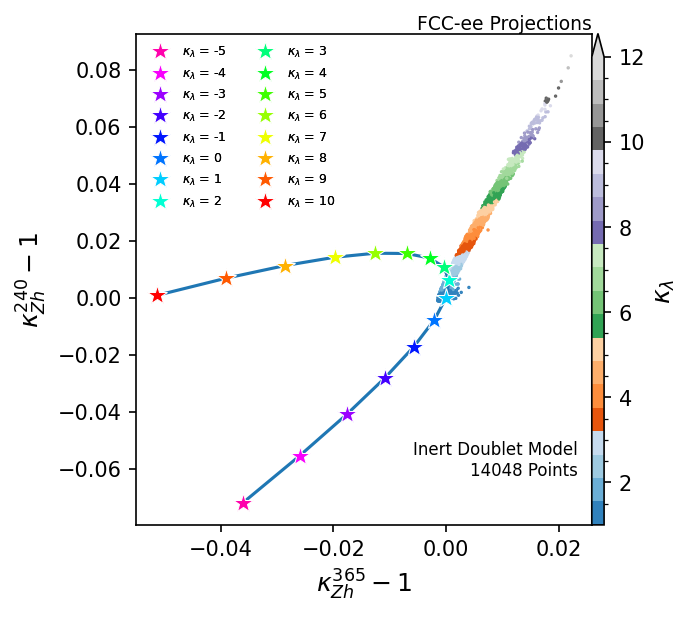

In [8]:
data_file = "data/IDM/allIDMpoints_2025-01-14"
plot_dir = "plots/IDM"
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        plot_self_consistent_curve='CH',
                        model_name=model_name,
                        upper_right_text=upper_right_text,
                )

Processing data file: data/IDM/allIDMpoints_2025-01-14


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

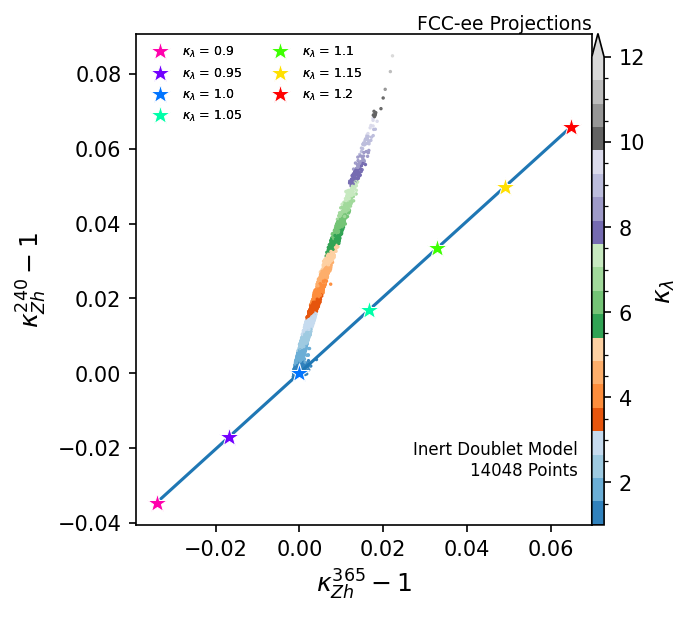

In [9]:
data_file = "data/IDM/allIDMpoints_2025-01-14"
plot_dir = "plots/IDM"
plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        plot_self_consistent_curve='CHbox',
                        model_name=model_name,
                        upper_right_text=upper_right_text,
                )

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

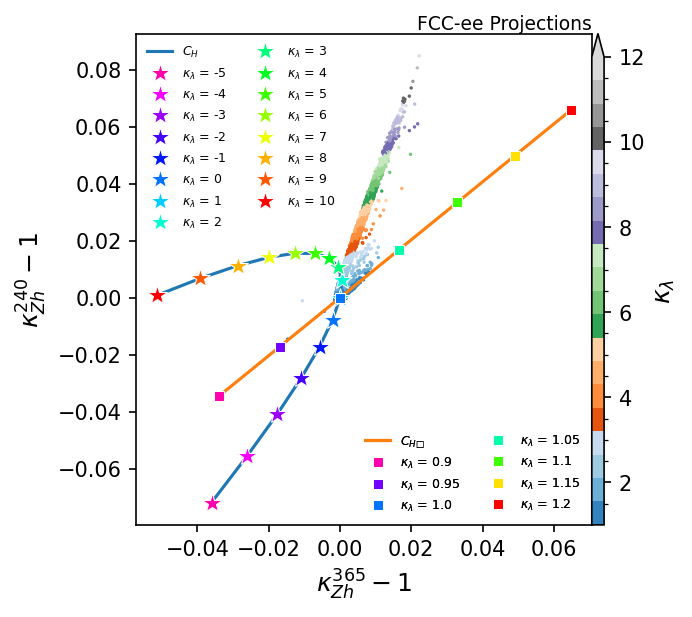

In [10]:
# data_file = "data/IDM/allIDMpoints_2025-01-14"
data_file = ["data/IDM/allIDMpoints_2025-01-14",
             "data/IDM/outlierIDMpoints_2025-01-17",
             "data/IDM/outlierIDMpoints2_2025-01-17",
             "data/IDM/outlierIDMpoints3_2025-01-17",
             "data/IDM/outlierIDMpoints4_2025-01-17",
             ]
plot_dir = "plots/IDM"
plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        plot_self_consistent_curve=['CH', 'CHbox'],
                        no_model_text=True, upper_right_text=upper_right_text,
                )

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


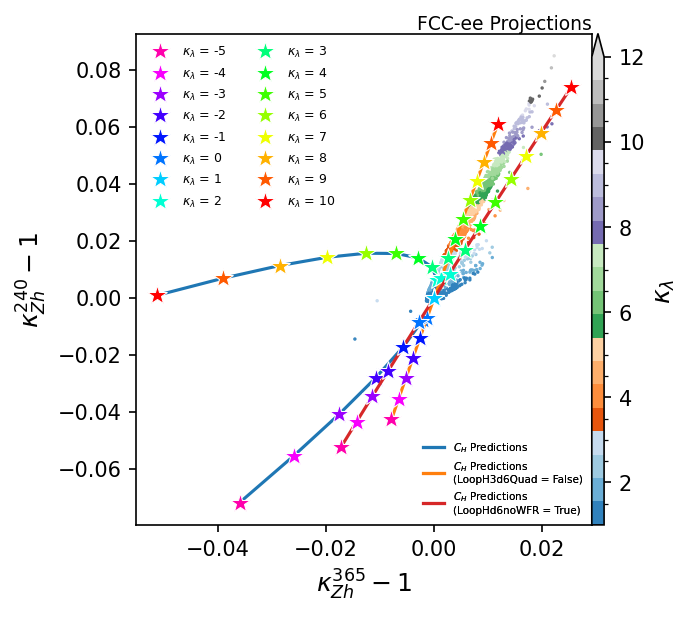

In [11]:
data_file = ["data/IDM/allIDMpoints_2025-01-14",
             "data/IDM/outlierIDMpoints_2025-01-17",
             "data/IDM/outlierIDMpoints2_2025-01-17",
             "data/IDM/outlierIDMpoints3_2025-01-17",
             "data/IDM/outlierIDMpoints4_2025-01-17",
             ]
plot_dir = "plots/IDM"
plot_name = "IDM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves"
fig, ax = plot_EffZZH_240_vs_365(
    data_file, read_IDM_file, no_model_text=True, upper_right_text=upper_right_text,
)

file_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee"
files = [
    f"{file_dir}/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions.txt",
    f"{file_dir}/large_kappa_lambda_fits_noLoopH3d6Quad/comparison_plots/k_ZH_240_365_predictions.txt",
    # f"{file_dir}/large_kappa_lambda_fits_noSubleading/comparison_plots/k_ZH_240_365_predictions.txt",
    f"{file_dir}/large_kappa_lambda_fits_LoopHd6noWFR/comparison_plots/k_ZH_240_365_predictions.txt",
]
labels = [
    # r'$C_{H}$ Predictions'+' \n(LoopH3d6Quad = True)',
    r'$C_{H}$ Predictions'+'',
    r'$C_{H}$ Predictions'+' \n(LoopH3d6Quad = False)',
    # r'$C_{H}$ Predictions'+' \n(LoopHd6NoSubleading = True)',
    r'$C_{H}$ Predictions'+' \n(LoopHd6noWFR = True)',
    # r'$C_{H\u25A1}$',
]
curves = ["CH" for _ in range(len(files))]
markers = ["*" for _ in range(len(files))]
markersizes = [10 for _ in range(len(files))]
colors = ["tab:blue", "tab:orange", "tab:red",]

fig, ax = plot_self_consistent_curve(
    curves, 
    files, 
    fig, 
    ax, 
    labels, 
    colors, 
    markers, 
    markersizes, 
    n_legends=1
)
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14
Number of points satisfying the 5% SM constraint on the single higgs couplings: 14014 / 14048


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

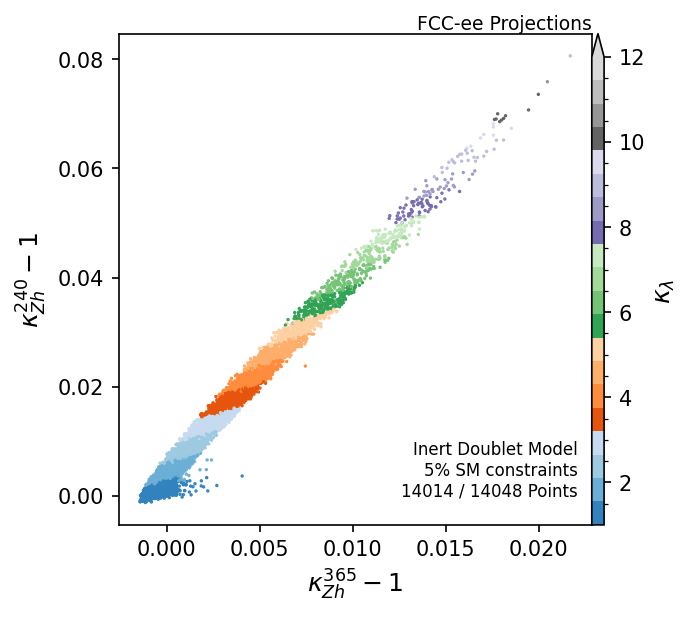

In [12]:
data_file = "data/IDM/allIDMpoints_2025-01-14"
BR_constraints = 0.05
plot_EffZZH_240_vs_365(data_file, read_IDM_file, model_name=model_name, upper_right_text=upper_right_text,
                       BR_constraints=BR_constraints
                )

Processing data file: data/IDM/allIDMpoints_2025-01-14
Number of points satisfying the 5% SM constraint on the single higgs couplings: 14014 / 14048


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

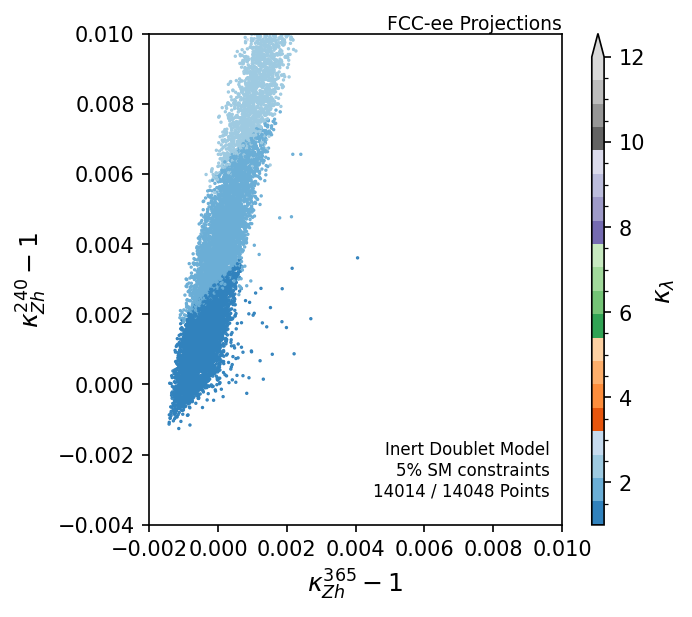

In [13]:
data_file = "data/IDM/allIDMpoints_2025-01-14"
BR_constraints = 0.05
plot_EffZZH_240_vs_365(data_file, read_IDM_file, model_name=model_name, upper_right_text=upper_right_text,
                       BR_constraints=BR_constraints,
                       zoom=True,
                       zoom_range_x=(-0.002, 0.01), 
                       zoom_range_y=(-0.004, 0.01),
                )

Processing data file: data/IDM/allIDMpoints_2025-01-14
Number of points satisfying the 1% SM constraint on the single higgs couplings: 533 / 14048


(<Figure size 675x600 with 2 Axes>,
 <Axes: xlabel='$\\kappa_{Zh}^{365} - 1$', ylabel='$\\kappa_{Zh}^{240} - 1$'>)

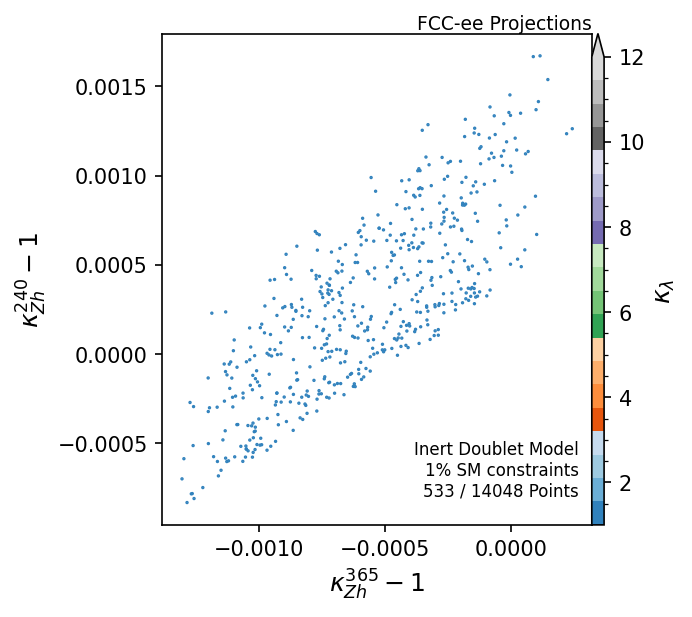

In [14]:
data_file = "data/IDM/allIDMpoints_2025-01-14"
BR_constraints = 0.01
plot_EffZZH_240_vs_365(data_file, read_IDM_file, model_name=model_name, upper_right_text=upper_right_text,
                       BR_constraints=BR_constraints
                )

### Finding Outlier Points 

In [67]:
from utils.common_utils import find_benchmark

BR_constraints=0.05
data_file="data/IDM/allIDMpoints_2025-01-14"
df = pd.read_csv(data_file + ".csv")

df = df.replace("", np.nan)
df = df.dropna()
old_df_indices = df.index.to_numpy()
df = df.reset_index(drop=True)

kappas, EWPOs, model_pars = read_IDM_file(df)
n_pts = df.shape[0]

output_dir = "./scan_output/IDM_scan_output"
subprocess.run(["mkdir", "-p", output_dir])

BP_filename = f"{output_dir}/Benchmark_Points_outliers.txt"
BR_constraint=0.05
with open(BP_filename, "w") as BP_output_file:

    max_errors_365 = [1e-3, 1e-3, 1e-3, 1e-3, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 2e-4, 4e-4, 4e-4, 4e-4]
    max_errors_240 = [1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 2e-3, 2e-3, 2e-3]
    delta_kappas_z_365 = [0.0075, 0.004, -0.0024, 0.001, 0.0001, 0.0024, 0.0017, 0.0046, 0.0040, 0.0068, 0.0063, 0.0092, 0.0086, 0.0116, 0.011, 0.0140, 0.0140, 0.0165, 0.0164, 0.0195, 0.022]
    delta_kappas_z_240 = [0.023, 0.004, -0.0020, -0.0005, 0.008, 0.009, 0.016, 0.017, 0.0225, 0.025, 0.0325, 0.033, 0.040, 0.041, 0.049, 0.051, 0.058, 0.060, 0.066, 0.071, 0.08]

    BP_Names = ["BPO_0", "BPO_1"]
    BP_Names = BP_Names + [f"BPB_{i}" for i in range(len(delta_kappas_z_240)-2)]
    BP_Names_legend = ["BPO 0", "BPO 1"]
    BP_Names_legend = BP_Names_legend + [f"BPB {i}" for i in range(len(delta_kappas_z_240)-2)]

    bp_kappas , bp_EWPOs, bp_model_pars, bp_indices = find_benchmark(n_pts=n_pts,
                               kappas=kappas,
                               EWPOs=EWPOs,
                               model_pars=model_pars,
                               old_df_indices=old_df_indices,
                               BP_Names=BP_Names,
                               BP_output_file=BP_output_file,
                               max_errors_365=max_errors_365,
                               max_errors_240=max_errors_240,
                               delta_kappas_z_365=delta_kappas_z_365,
                               delta_kappas_z_240=delta_kappas_z_240,
                               BR_constraints=BR_constraints,
                              )


elif BP == "BPO_0":
    kappas['uu'] = 0.9818547810617284
    kappas['dd'] = 0.9818547810617284
    kappas['ss'] = 0.9818547810617284
    kappas['cc'] = 0.9818547810617284
    kappas['bb'] = 0.9818547810617284
    kappas['tt'] = 0.9818547810617284
    kappas['ee'] = 0.9818547810617284
    kappas['mumu'] = 0.9818547810617284
    kappas['tautau'] = 0.9818547810617284
    kappas['ZZ_0'] = 1.007141704579298
    kappas['ZZ_240'] = 1.0237693288776533
    kappas['ZZ_365'] = 1.0074536101415776
    kappas['ZZ_500'] = 1.0026988104523176
    kappas['ZZ_550'] = 1.0021232678597285
    kappas['ZZ'] = 0.9899392240917029
    kappas['WW'] = 0.9899392240917029
    kappas['lam'] = 4.038636858901748
    kappas['gamgam'] = 0.9514322699531608
    kappas['Zgam'] = 0.9820015140523058
    kappas['ZZ_0_with_WFR'] = 0.9953498248226368
    kappas['ZZ_240_with_WFR'] = 1.0119172507528293
    kappas['ZZ_365_with_WFR'] = 0.9956631382646509
    kappas['ZZ_500_with_WFR'] = 0.990876120168658
    kappas['ZZ_550_with_WFR

In [16]:
print("std::vector<float> base_KappaLambdas = {")
for BP, BP_name in zip(bp_kappas, BP_Names):
    print(f"        {BP['lam']}, // {BP_name}")
print("    };")

std::vector<float> base_KappaLambdas = {
        4.038636858901748, // BPO_0
        1.2385642568656816, // BPO_1
        1.1209067864736006, // BPB_0
        1.1119460475058272, // BPB_1
        2.3867362274064843, // BPB_2
        2.296737570137434, // BPB_3
        3.3446699219962595, // BPB_4
        3.3186760761499228, // BPB_5
        4.332584967850238, // BPB_6
        4.324280052220163, // BPB_7
        5.390968560325193, // BPB_8
        5.289906405452073, // BPB_9
        6.370034303736775, // BPB_10
        6.270579956517072, // BPB_11
        7.515862276796717, // BPB_12
        7.466008740779396, // BPB_13
        8.611459058586306, // BPB_14
        8.459762817722257, // BPB_15
        9.319513844125106, // BPB_16
        9.888810967739037, // BPB_17
        11.2535829810942, // BPB_18
    };


### Plotting the obtained points

Processing data file: data/IDM/allIDMpoints_2025-01-14
Number of points satisfying the 5% SM constraint on the single higgs couplings: 14014 / 14048


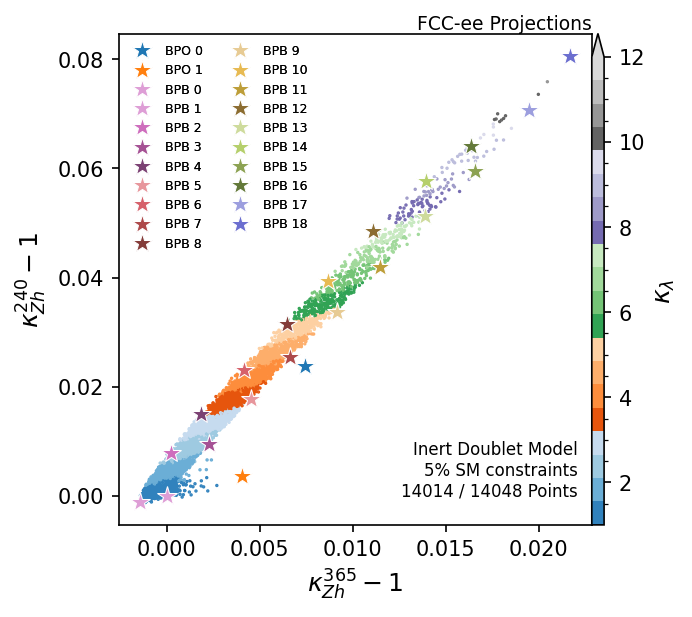

In [17]:
data_file = "data/IDM/allIDMpoints_2025-01-14"
plot_dir = "plots/IDM"
BR_constraints = 0.05
plot_points = [(BP["ZZ_365"]-1, BP["ZZ_240"]-1, BP["lam"], label) for BP, label in zip(bp_kappas, BP_Names_legend)]
colors = mpl.colormaps['tab20b']
color = ["tab:blue", "tab:orange"] + list(colors(np.linspace(0.001, 0.999, len(plot_points)+1)[::-1]))

plot_EffZZH_240_vs_365(data_file, read_IDM_file, model_name=model_name, upper_right_text=upper_right_text,
                       BR_constraints=BR_constraints,
                       plot_points=plot_points,
                       point_colors=color
                )
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"all_BPs.pdf")

## Plotting the obtained points including the Higgs self-energy contributions to $\sigma_{Zh}$

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


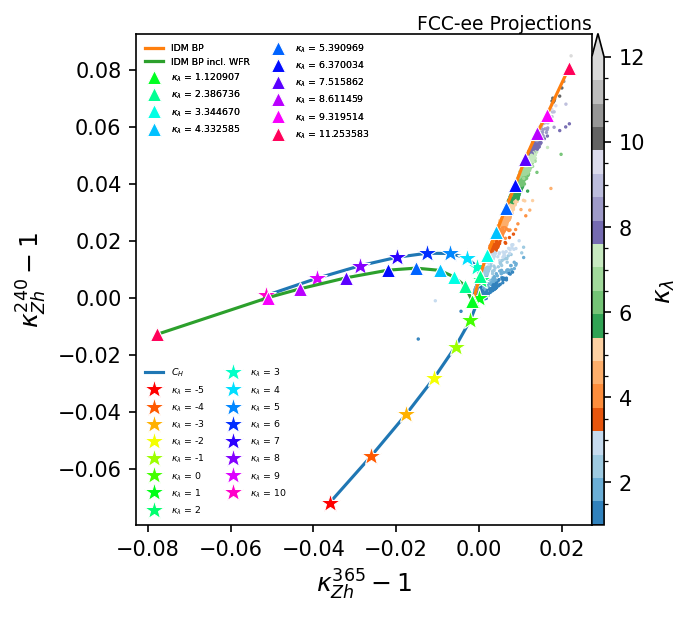

In [18]:
plot_points = [(BP["ZZ_365"]-1, BP["ZZ_240"]-1, BP["lam"], label) for BP, label in zip(bp_kappas, BP_Names_legend)]

plot_points_with_WFR = [
    (sqrt( (BP["ZZ_365"])**2 + ZZh_hextleg( BP["lam"] ) ) - 1,
     sqrt( (BP["ZZ_240"])**2 + ZZh_hextleg( BP["lam"] ) ) - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]

# Plot only the even-numbered BPBs
plot_points = plot_points[2::2]
plot_points_with_WFR = plot_points_with_WFR[2::2]


data_file = ["data/IDM/allIDMpoints_2025-01-14",
             "data/IDM/outlierIDMpoints_2025-01-17",
             "data/IDM/outlierIDMpoints2_2025-01-17",
             "data/IDM/outlierIDMpoints3_2025-01-17",
             "data/IDM/outlierIDMpoints4_2025-01-17",
             ]

plot_dir = "plots/IDM"
plot_name = "IDM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves_with_WFR"

fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                )

curves = ["CH", "IDM", "IDM_SMEFT",]
file_names = [
    "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions.txt",
    # "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits_CHbox/comparison_plots/k_ZH_240_365_predictions.txt",
    None,
    None,
]
data_sets = [
    None,
    plot_points,
    plot_points_with_WFR,
]
legend_locs = ['lower left', None, 'upper left']
legend_fontsizes = [4.5, 4.5, 4.5]
legend_cols = [2, 2, 2]
markers = ['*', '^', '^']
color_lines = ["tab:blue", "tab:orange", "tab:green"]
label_lines = [r'$C_{H}$', r'IDM BP', r'IDM BP incl. WFR']
markersizes = [10, 7, 7]


plot_curves(ax, curves, file_names, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")

Similar plot, but now instead of assuming integer values for $\kappa_\lambda$ for the points in the SMEFT curves, we take $\kappa_\lambda$ values corresponding to the IDM BPs

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


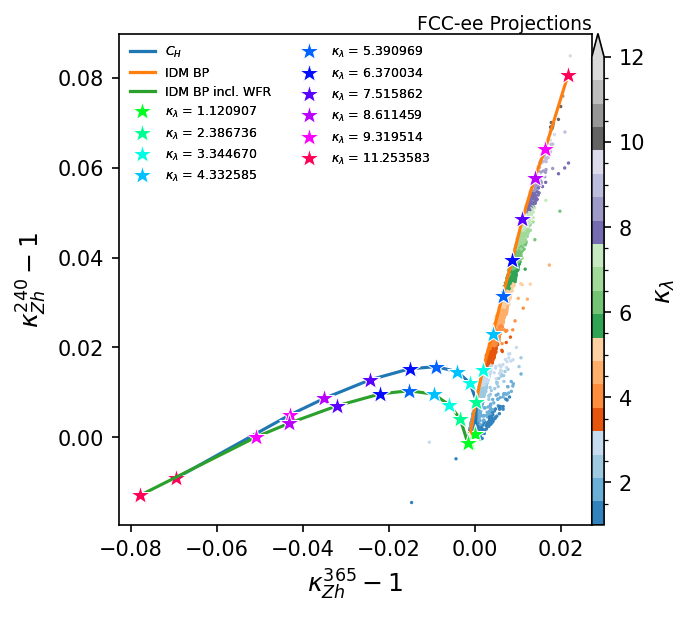

In [19]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                )

legend_locs = [None, None, 'upper left',]
legend_fontsizes = [6.0, 6.0, 6.0,]
markers = ["*", "*", "*", ]
markersizes = [10, 10, 10, ]
curves_matching_lambdas = [
    "CH_matching_lambdas", 
    # "CHbox", 
    "IDM",
    "IDM_SMEFT",
]
file_names_matching_lambdas = [
    "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions_general_lambdas.txt",
    # "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits_CHbox/comparison_plots/k_ZH_240_365_predictions_general_lambdas.txt",
    None,
    None,
]

plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas.pdf")

# Comparing IDM and SMEFT

### Consistency check using interpolation in $C_H$ vs. $C_{H□}$ grid
The `generate_HEPfit_predictions` directory contains the setup and results for SMEFT predictions on a grid of points in the $C_H$ vs. $C_{H□}$ plane. Predictions for $\kappa_{Zh}^{240}$, $\kappa_{Zh}^{365}$, and $\kappa_\lambda$, for each point in the grid, are stored in the `input_file` read below. 

In [20]:
input_file = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/generate_HEPfit_predictions/results/k_ZH_240_365_central_value_results.txt"

k_ZH_240 = []
k_ZH_365 = []
lmbd = []
CH = []
CHBox = []

with open(input_file, "r") as f:
    for i, line in enumerate(f):
        if i == 0:
            continue  # skip header if there is one
        columns = line.strip().split(",")
        if len(columns) < 5:
            continue  # skip malformed lines
        k_ZH_240.append(float(columns[0]))
        k_ZH_365.append(float(columns[1]))
        lmbd.append(float(columns[2]))
        CH.append(float(columns[3]))
        CHBox.append(float(columns[4]))

print(len(CH))

from scipy.interpolate import LinearNDInterpolator
import numpy as np

interp = LinearNDInterpolator(list(zip(k_ZH_365, k_ZH_240)), lmbd)

1620


plot_points_interpolation = ((-0.0016167481744658874, -0.001275615143331632, nan, 'BPB 0'), (-0.0034064653469969564, 0.004148880824787815, 0.04909043494968435, 'BPB 2'), (-0.0059971707283719144, 0.007147773796899237, 0.016794680920406257, 'BPB 4'), (-0.009540856273253184, 0.00934200877741631, -0.009607818832997772, 'BPB 6'), (-0.015248488724726283, 0.009885451202404694, -0.04574984676917637, 'BPB 8'), (-0.02200200555171372, 0.008905195687072043, -0.06466684660387578, 'BPB 10'), (-0.03214068027270489, 0.005827586491907288, -0.11585445509434233, 'BPB 12'), (-0.04330771565184288, 0.0014605175285289373, -0.14643666902985686, 'BPB 14'), (-0.051022600280268504, -0.00199819504044485, -0.12752755464714483, 'BPB 16'), (-0.07803688285072152, -0.016172792760283383, -0.18025642846484224, 'BPB 18'))
Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDM

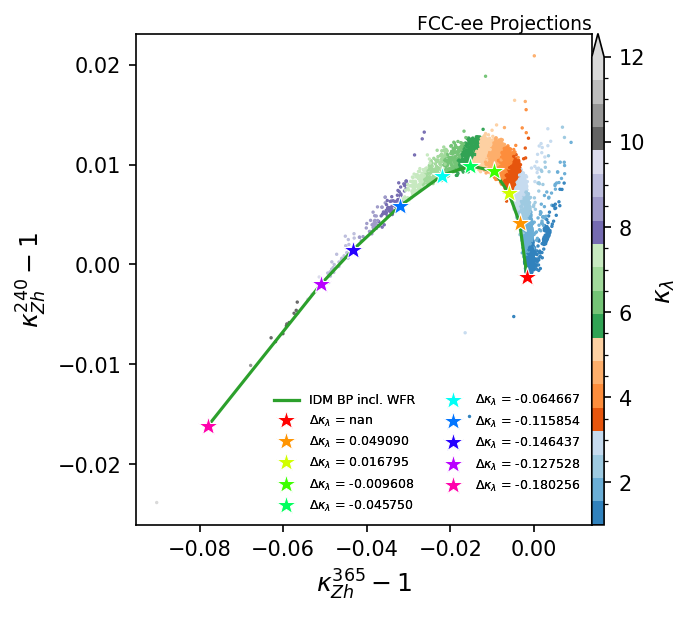

In [21]:
# x = np.array([sqrt( (BP["ZZ_365"])**2 + ZZh_hextleg( BP["lam"] ) ) - 1 for BP in bp_kappas])
x = np.array([BP["ZZ_365_with_WFR"] - 1 for BP in bp_kappas])
# y = np.array([sqrt( (BP["ZZ_240"])**2 + ZZh_hextleg( BP["lam"] ) ) - 1 for BP in bp_kappas])
y = np.array([BP["ZZ_240_with_WFR"] - 1 for BP in bp_kappas])
lmbd_BPs = np.array([BP["lam"] for BP in bp_kappas])

X, Y = np.meshgrid(np.array(x)+1, np.array(y)+1)  # 2D grid for interpolation
Z = interp(X, Y)
Z = np.array([Z[i,i] for i in range(Z.shape[0])])


plot_points_interpolation = tuple(zip(x, y, lmbd_BPs-Z, BP_Names_legend))
plot_points_interpolation = plot_points_interpolation[2::2]
print(f"plot_points_interpolation = {plot_points_interpolation}")

plot_dir = "plots/IDM"; plot_name = "IDM_results_k_ZH_240_vs_365"; plot_name_suffix = "_with_self_consistent_curves_with_WFR"
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file, func_read_file_args={"data_with_WFR": True},
                        no_model_text=True, upper_right_text=upper_right_text,
                )
data_sets = [plot_points_interpolation]
legend_locs = ['best']
legend_fontsizes = [6.0]
markers = ["*"]
markersizes = [10]
curves_matching_lambdas = ["IDM_smeft"]
file_names_matching_lambdas = [None]
color_lines = ["tab:green"]
label_lines = [r'IDM BP incl. WFR']
legend_cols = [2]
klam_in_point_labels = r"$\Delta \kappa_{\lambda}$"
plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, 
           markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas_dkala_interp.pdf")


### Consistency check using analytical formula
Instead of using the interpolated values on the grid, we can also use the HEPfit analytical formula for $\kappa_{Zh}^{240}$ and $\kappa_{Zh}^{365}$. By inverting these, one can obtain a value for $\kappa_\lambda$ given a set of predictions for $\kappa_{Zh}^{240}$, $\kappa_{Zh}^{365}$

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


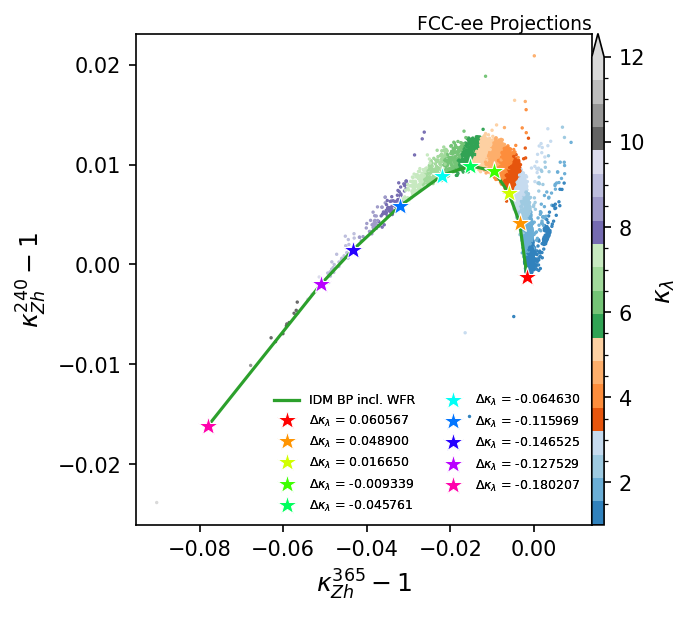

In [22]:
from utils.common_utils import analytical_formula_CH_CHBox as analytical_formula
from utils.common_utils import analytical_formula_CH_CHBox_general_C1

plot_points_analytical_formula = []
for BP, label in zip(bp_kappas, BP_Names_legend):
    # k_ZH_365 = sqrt( (BP["ZZ_365"])**2 + ZZh_hextleg( BP["lam"] ) )
    k_ZH_365 = BP["ZZ_365_with_WFR"] 
    # k_ZH_240 = sqrt( (BP["ZZ_240"])**2 + ZZh_hextleg( BP["lam"] ) )
    k_ZH_240 = BP["ZZ_240_with_WFR"] 
    CH, CHBox, lmbd = analytical_formula(mu_240=k_ZH_240**2, mu_365=k_ZH_365**2)

    plot_points_analytical_formula.append((k_ZH_365-1, k_ZH_240-1, BP["lam"]-lmbd, label))

plot_points_analytical_formula = plot_points_analytical_formula[2::2]
data_sets = [plot_points_analytical_formula,]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file, func_read_file_args={"data_with_WFR": True},
                        no_model_text=True, upper_right_text=upper_right_text, 
                )

plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas_dkala_analytical.pdf")

# Cross-checks using the HEPfit SMEFT expressions for the IDM points
We can repeat the process above, but instead of using the IDM predictions for $\kappa_{Zh}^{240}$, $\kappa_{Zh}^{365}$, we use the SMEFT expressions in HEPfit. The `smeft_sigma_Zh` function implements the $\kappa_\lambda$-dependent part of these expressions. Additionally, the BSM corrections to the Higgs external leg, the IDM contribution corresponding to $C_{H□}$, are also added separately. Since these correspond to the Higgs coupling modifier to fermions, for simplicity we take it directly as `2*(BP["uu"]-1))`.

With these predictions, we then use both the interpolating procedure and the inverse of the HEPfit analytical formulas to obtain corresponding SMEFT predictions for $\kappa_\lambda$ for each IDM BP. Since we are now using the HEPfit expressions themselves to obtain the "IDM" predictions for $\kappa_{Zh}$, we expect that the $\kappa_\lambda$ prediction for each IDM BP will match the SMEFT value extracted using these procedures. 

Compare `smeft_formula` IDM predictions with self-consistent SMEFT with $C_H \neq 0$

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


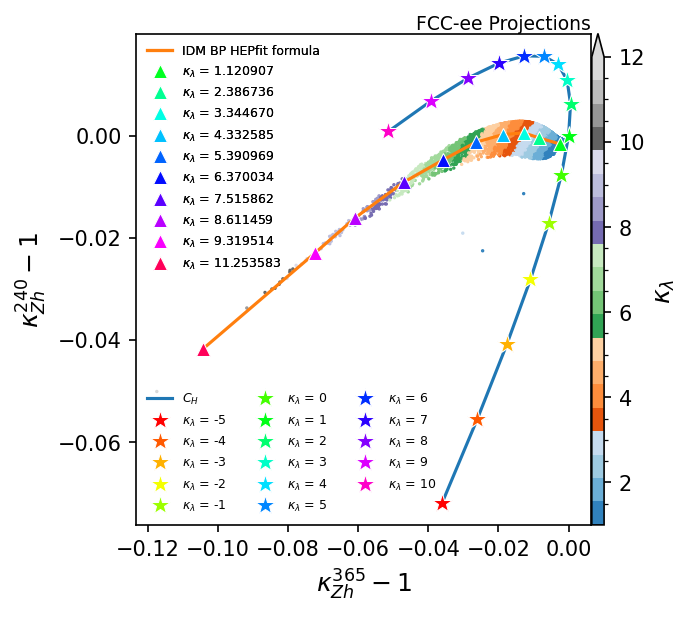

In [23]:
plot_points = [(BP["ZZ_365"]-1, BP["ZZ_240"]-1, BP["lam"], label) for BP, label in zip(bp_kappas, BP_Names_legend)]

plot_points_HEPfit_formula = [
    (sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=365) + 2*(BP["uu"]-1)) - 1,
     sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=240) + 2*(BP["uu"]-1)) - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]

# Plot only the even-numbered BPBs
plot_points = plot_points[2::2]
plot_points_HEPfit_formula = plot_points_HEPfit_formula[2::2]

data_file = ["data/IDM/allIDMpoints_2025-01-14",
             "data/IDM/outlierIDMpoints_2025-01-17",
             "data/IDM/outlierIDMpoints2_2025-01-17",
             "data/IDM/outlierIDMpoints3_2025-01-17",
             "data/IDM/outlierIDMpoints4_2025-01-17",
             ]

plot_dir = "plots/IDM"
plot_name = "IDM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves_SMEFT_formula"

fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={"smeft_formula": True},
                )

curves = ["CH", "IDM_HEPfit",]
file_names = [
    "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions.txt",
    # "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits_CHbox/comparison_plots/k_ZH_240_365_predictions.txt",
    None,
]
data_sets = [None, plot_points_HEPfit_formula,]
legend_locs = ['lower left', 'upper left',]
legend_cols = [3, 1,]
legend_fontsizes = [6.0, 6.0,]
markers = ["*", "^",]
color_lines = ["tab:blue", "tab:orange",]
label_lines = [r'$C_{H}$', r'IDM BP HEPfit formula',]
markersizes = [10, 7,]

plot_curves(ax, curves, file_names, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")


Instead of using SMEFT predictions corresponding to integer values of $\kappa_\lambda$, obtain predictions for the same values of $\kappa_\lambda$ as the IDM benchmarks:

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


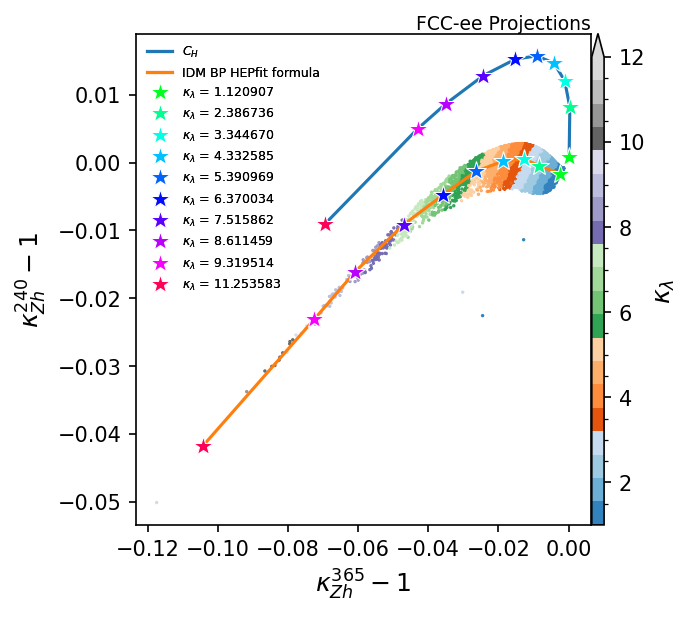

In [24]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file, 
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={"smeft_formula": True},
                )

legend_locs = [None, 'upper left',]
legend_fontsizes = [6.0, 6.0,]
markers = ["*", "*", ]
markersizes = [10, 10, ]
curves_matching_lambdas = ["CH_matching_lambdas", "IDM_HEPfit"]
file_names_matching_lambdas = [
    "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/Fits_HLLHC_FCCee/large_kappa_lambda_fits/comparison_plots/k_ZH_240_365_predictions_general_lambdas.txt",
    None,
]
plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas.pdf")

#### Cross-check using interpolation in the $C_H$ vs. $C_{H□}$ plane

plot_points_interpolation = ((-0.0023578543246557393, -0.0016733512948496898, nan, 'BPB 0'), (-0.008352361877010273, -0.0004825376389878677, -0.00014273566842870622, 'BPB 2'), (-0.012792009501325863, 0.0005370491006257971, -0.00025738107859840653, 'BPB 4'), (-0.018833601524379517, 0.0001728408801791037, -0.0006532179517861891, 'BPB 6'), (-0.026469189861152764, -0.001310767545141256, -0.0006765195393168, 'BPB 8'), (-0.03570122783799479, -0.004734452708536341, -0.0006207272275311482, 'BPB 10'), (-0.047014440482315956, -0.00913637649924981, -0.000508696196449776, 'BPB 12'), (-0.0607948330195065, -0.016071225624089247, -0.0005318404664773624, 'BPB 14'), (-0.07243551312020968, -0.023072989543649447, -0.0008127437469998, 'BPB 16'), (-0.1043255928164798, -0.041825625801902966, -0.001086368460713416, 'BPB 18'))
Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'da

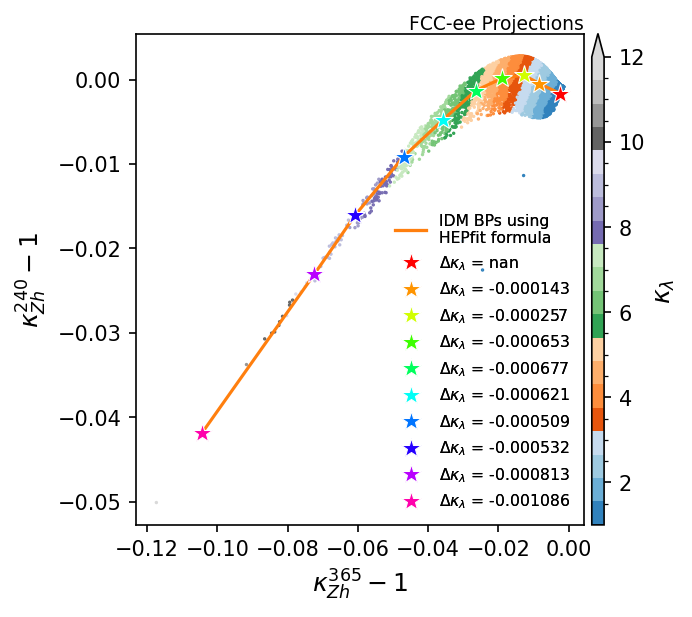

In [25]:
x = np.array([sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=365) + 2*(BP["uu"]-1)) - 1 for BP in bp_kappas])
y = np.array([sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=240) + 2*(BP["uu"]-1)) - 1 for BP in bp_kappas])
lmbd_BPs = np.array([BP["lam"] for BP in bp_kappas])

X, Y = np.meshgrid(np.array(x)+1, np.array(y)+1)  # 2D grid for interpolation
Z = interp(X, Y)
Z = np.array([Z[i,i] for i in range(Z.shape[0])])

plot_points_interpolation = tuple(zip(x, y, lmbd_BPs-Z, BP_Names_legend))
plot_points_interpolation = plot_points_interpolation[2::2]
print(f"plot_points_interpolation = {plot_points_interpolation}")

fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
    no_model_text=True, upper_right_text=upper_right_text,
    func_read_file_args={'smeft_formula': True},
)

data_sets = [plot_points_interpolation,]
legend_locs = ['lower right',]
legend_fontsizes = [6.0,]
markers = ["*", ]
markersizes = [10, ]
curves_matching_lambdas = ["IDM_HEPfit",]
file_names_matching_lambdas = [None,]
color_lines = ["tab:orange",]
label_lines = ['IDM BPs using\nHEPfit formula',]
legend_cols = [1,]
legend_fontsizes = [7.5,]
klam_in_point_labels = r"$\Delta \kappa_{\lambda}$"
plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas_dkala_interp.pdf")

#### Cross-check using analytical formula

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


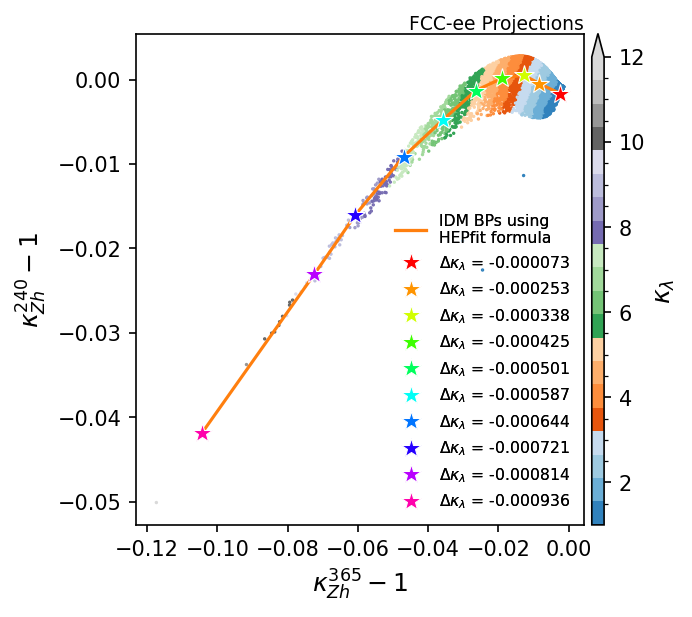

In [26]:
plot_points_analytical_formula = []
for BP, label in zip(bp_kappas, BP_Names_legend):
    k_ZH_365 = sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=365) + 2*(BP["uu"]-1))
    k_ZH_240 = sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=240) + 2*(BP["uu"]-1))
    CH, CHBox, lmbd = analytical_formula(mu_240=k_ZH_240**2, mu_365=k_ZH_365**2)

    plot_points_analytical_formula.append((k_ZH_365-1, k_ZH_240-1, BP["lam"]-lmbd, label))

plot_points_analytical_formula = plot_points_analytical_formula[2::2]
data_sets = [plot_points_analytical_formula,]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={'smeft_formula': True},
                )

plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_matching_lambdas_dkala_analytical.pdf")

## Interpolation of $C_H$ vs. $C_{H□}$ curve
We have obtained ($C_H, C_{H□}$) pairs for each IDM BP, by inverting the SMEFT HEPfit expressions. Here we interpolate the relationship between $C_H$ and $C_{H□}$, using a piecewise-linear function.

CH values for IDM BPs: [ -0.27356358  -3.00840531  -5.06677076  -7.18922198  -9.45944754
 -11.56287914 -14.01502292 -16.36477805 -17.89280176 -22.03756072]
CH values for IDM BPs (sorted): [-22.03756072 -17.89280176 -16.36477805 -14.01502292 -11.56287914
  -9.45944754  -7.18922198  -5.06677076  -3.00840531  -0.27356358]
CHbox values for IDM BPs: [-0.04128562 -0.14302313 -0.19120722 -0.24003791 -0.28308977 -0.33146349
 -0.36362348 -0.40744107 -0.45990313 -0.52884078]
CHbox values for IDM BPs (sorted): [-0.52884078 -0.45990313 -0.40744107 -0.36362348 -0.33146349 -0.28308977
 -0.24003791 -0.19120722 -0.14302313 -0.04128562]
CH curve: [-22.   -21.12 -20.24 -19.36 -18.48 -17.6  -16.72 -15.84 -14.96 -14.08
 -13.2  -12.32 -11.44 -10.56  -9.68  -8.8   -7.92  -7.04  -6.16  -5.28
  -4.4   -3.52  -2.64  -1.76  -0.88   0.  ]
CHbox curve: [-0.52821606 -0.51357947 -0.49894288 -0.48430629 -0.4696697  -0.44985028
 -0.419637   -0.39765515 -0.38124515 -0.36483515 -0.35293441 -0.34139317
 -0.32863758 -0.3

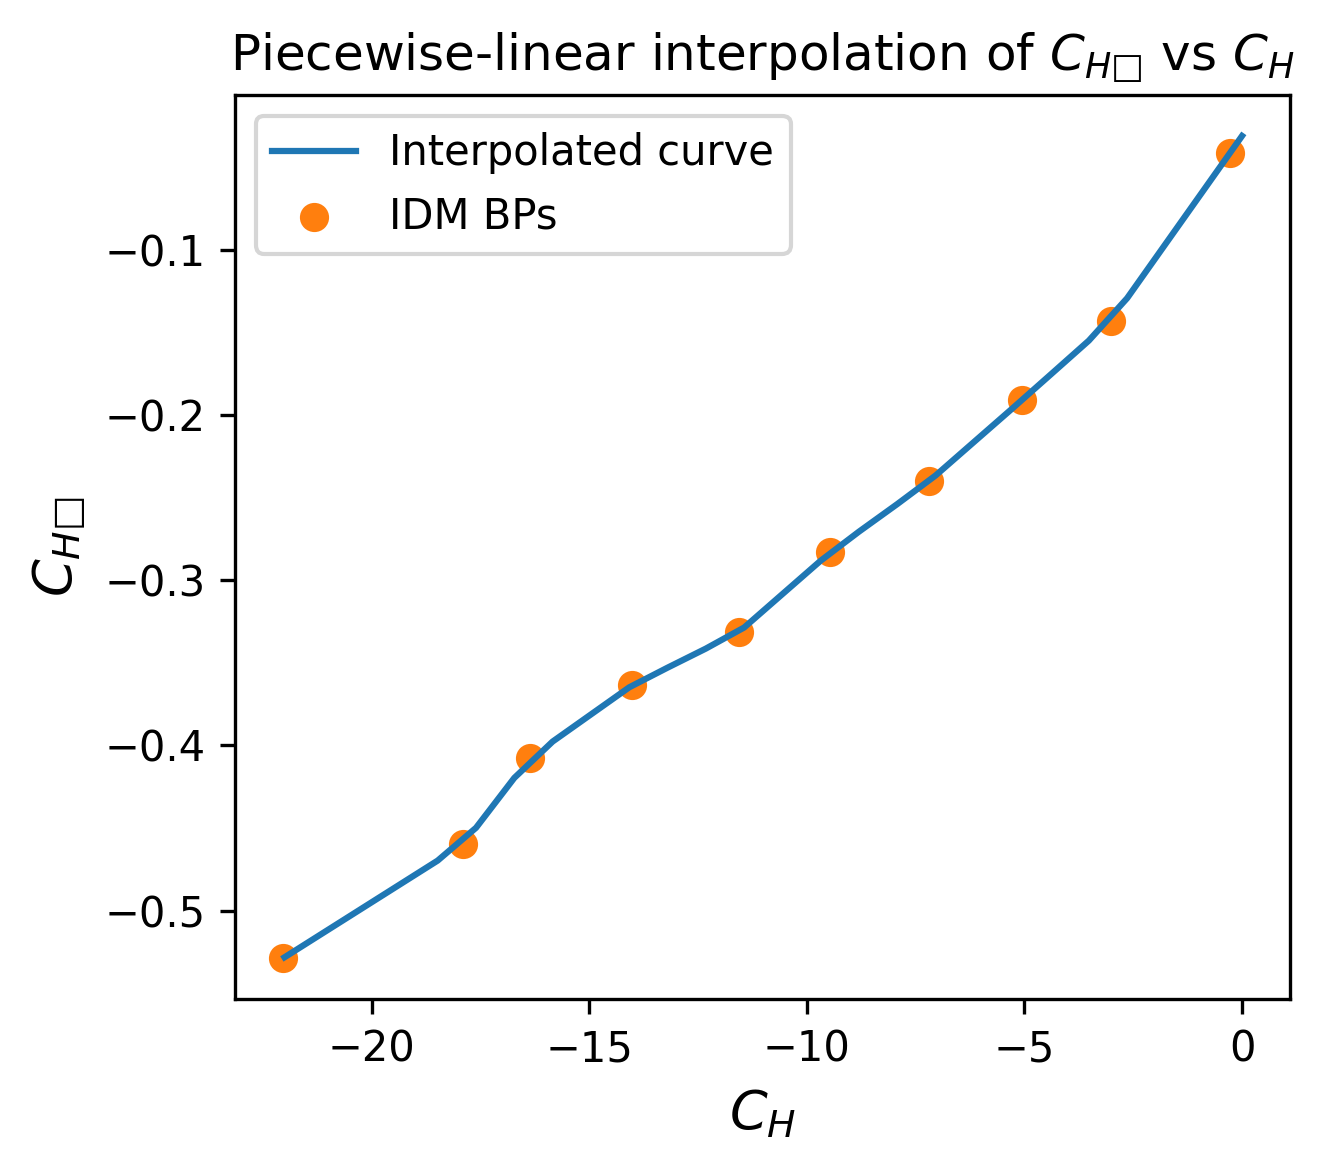

In [27]:
# from scipy.interpolate import CubicSpline
from scipy.interpolate import make_interp_spline

CH_BPs = []
CHbox_BPs = []
for BP in bp_kappas:
    k_ZH_365 = sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=365) + 2*(BP["uu"]-1))
    k_ZH_240 = sqrt(smeft_sigma_Zh(lmbd=BP["lam"], sqrt_s=240) + 2*(BP["uu"]-1))
    CH, CHBox, lmbd = analytical_formula(mu_240=k_ZH_240**2, mu_365=k_ZH_365**2)
    CH_BPs.append(CH)
    CHbox_BPs.append(CHBox)

CH_BPs = np.array(CH_BPs[2::2])
CHbox_BPs = np.array(CHbox_BPs[2::2])

sorted_indices = np.argsort(CH_BPs)
CH_BPs_sorted = CH_BPs[sorted_indices]
CHbox_BPs_sorted = CHbox_BPs[sorted_indices]

print(f"CH values for IDM BPs: {CH_BPs}")
print(f"CH values for IDM BPs (sorted): {CH_BPs_sorted}")
print(f"CHbox values for IDM BPs: {CHbox_BPs}")
print(f"CHbox values for IDM BPs (sorted): {CHbox_BPs_sorted}")
# CH_CHbox_interpolator = CubicSpline(CH_BPs_sorted, CHbox_BPs_sorted)
spline_degree = 1  # Linear interpolation
CH_CHbox_interpolator = make_interp_spline(CH_BPs_sorted, CHbox_BPs_sorted, k=spline_degree)

CH_curve = np.linspace(-22, 0, 26)
CHbox_curve = CH_CHbox_interpolator(CH_curve)
print(f"CH curve: {CH_curve}")
print(f"CHbox curve: {CHbox_curve}")

fig, ax = plt.subplots(figsize=(4.5, 4.),dpi=300)
plt.plot(CH_curve, CHbox_curve, label="Interpolated curve", color="tab:blue")
plt.scatter(CH_BPs, CHbox_BPs, color="tab:orange", label="IDM BPs")
plt.xlabel(r"$C_{H}$", fontsize=13)
plt.ylabel('$C_{H\u25A1}$', fontsize=13)
# plt.title("Cubic spline interpolation of $C_{H\u25A1}$ vs $C_{H}$")
plt.title("Piecewise-linear interpolation of $C_{H\u25A1}$ vs $C_{H}$")
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}'+"_CH_CHbox_Cubic_spline_interpolation.pdf")


output_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/"
with open(f"{output_dir}/CH_CHbox_interpolator_results.txt", "w") as f:
    for i in range(len(CH_curve)):
        f.write(f"{CH_curve[i]},{CHbox_curve[i]}\n")

with open(f"{output_dir}/CH_CHbox_BPs.txt", "w") as f:
    for i in range(len(CH_BPs)):
        f.write(f"{CH_BPs[i]},{CHbox_BPs[i]}\n")


## Plotting results for different calculation methods

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']
Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


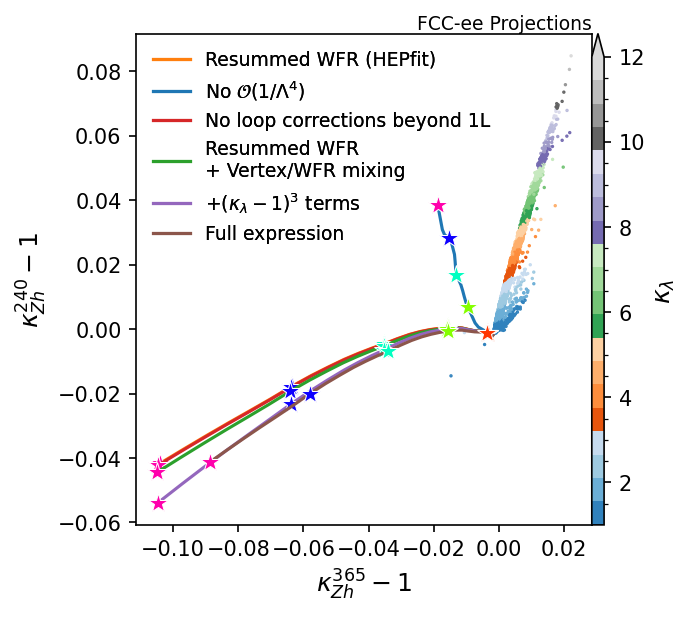

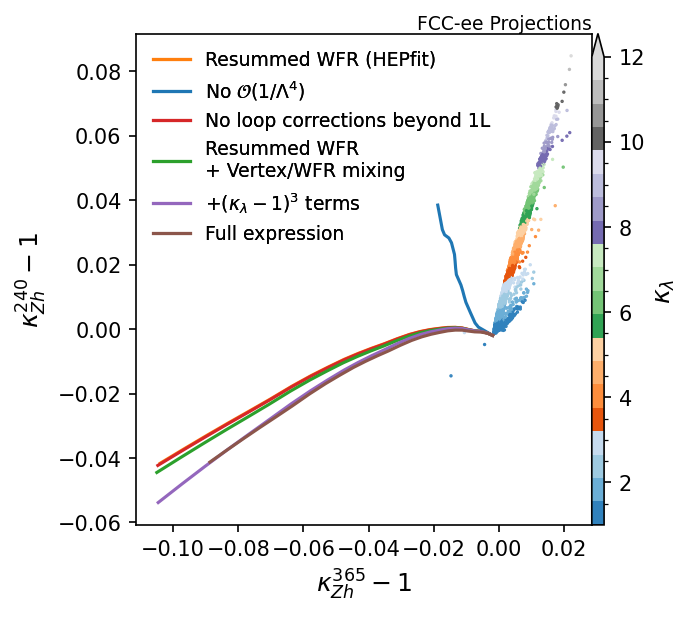

In [28]:
data_file = ["data/IDM/allIDMpoints_2025-01-14",
             "data/IDM/outlierIDMpoints_2025-01-17",
             "data/IDM/outlierIDMpoints2_2025-01-17",
             "data/IDM/outlierIDMpoints3_2025-01-17",
             "data/IDM/outlierIDMpoints4_2025-01-17",
             ]

plot_dir = "plots/IDM"
plot_name = "IDM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves_SMEFT_formula"

fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                )

legend_locs = [None, None, None, None, None, "upper left",]
legend_cols = [1 for _ in range(6)]
legend_fontsizes = [9.0 for _ in range(6)]
markers = ["*" for _ in range(6)]
markersizes = [10.0 for _ in range(6)]
color_lines = [
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [None for _ in range(6)]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    f"{results_directory}/k_ZH_240_365_predictions.txt",
    f"{results_directory}/k_ZH_240_365_predictions_noLoopH3d6Quad.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopHd6NoSubleading.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Quad_C1term.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Cubi.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Full.txt",
]

plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    max_n_markers=5,
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_markers.pdf")


fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                )
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    [None for _ in range(6)],  # No markers for this plot
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation.pdf")

### Plots including SM higgs contribution to WFR into IDM BPs

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']
Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']
Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


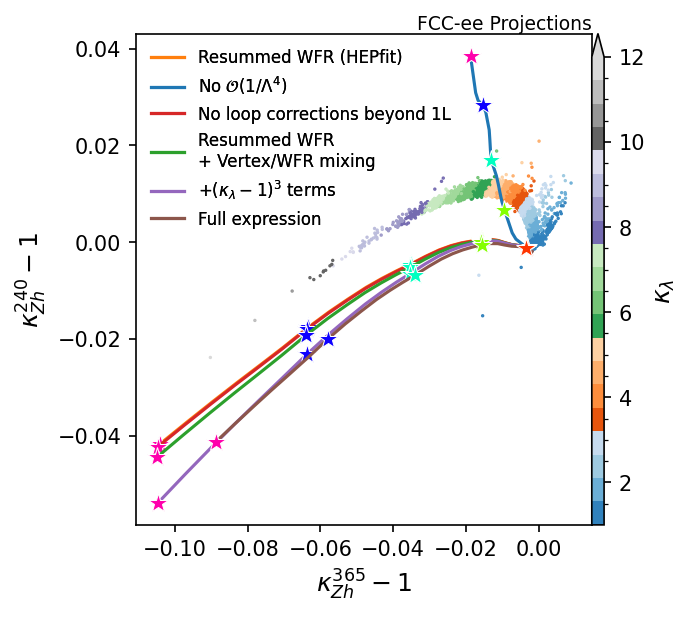

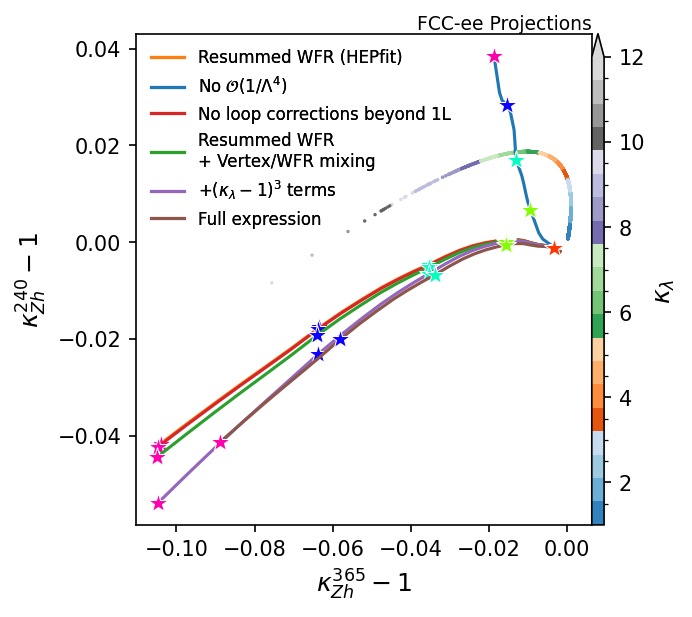

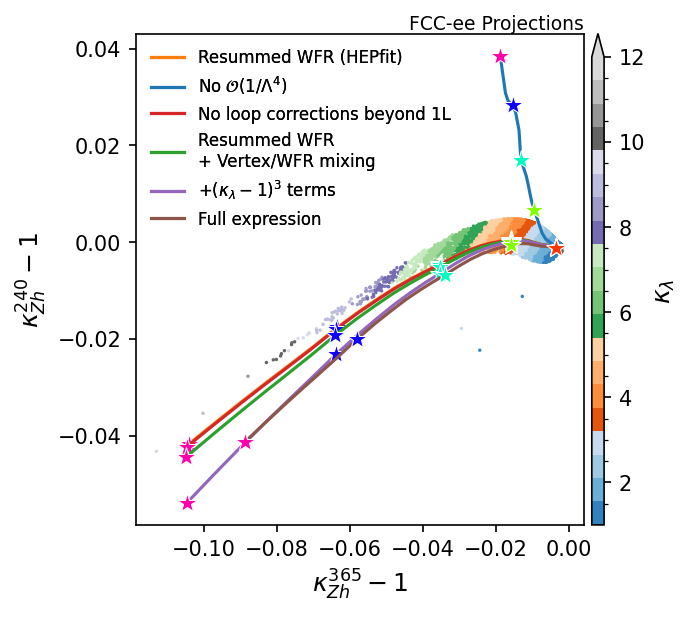

In [29]:
legend_fontsizes = [8.0 for _ in range(6)]

#####################
### data_with_WFR ###
#####################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={'data_with_WFR': True},
)
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    max_n_markers=5,
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_markers_with_IDM_WFR.pdf")



###################################
### data_with_WFR_no_BSM_vertex ###
###################################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={'data_with_WFR': False,
                                             'data_with_WFR_no_BSM_vertex': True},
)
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    max_n_markers=5,
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_markers_with_IDM_WFR_no_BSM_vertex.pdf")


#######################################
### data_with_WFR_ZZh1L_hextlegonly ###
#######################################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={'data_with_WFR': False,
                                             'data_with_WFR_no_BSM_vertex': False,
                                             'data_with_WFR_ZZh1L_hextlegonly': True}
)
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    max_n_markers=5,
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_markers_with_IDM_WFR_ZZh1L_hextlegonly.pdf")

### Plots for presentations

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


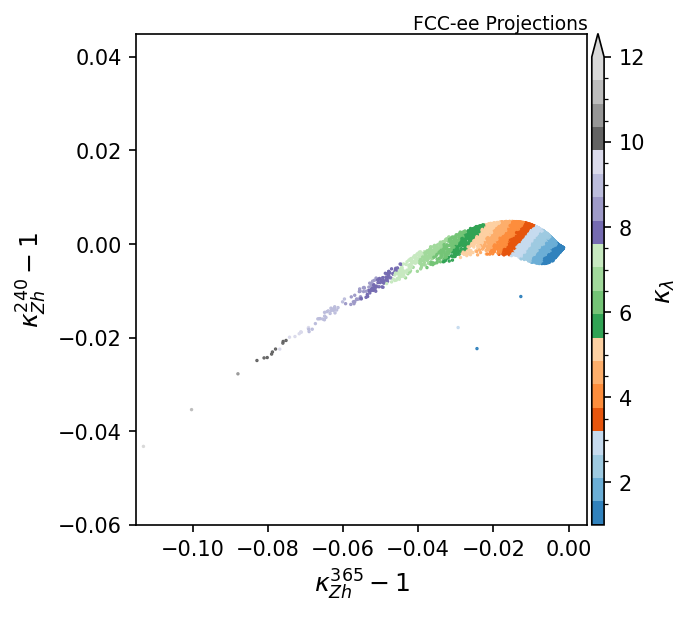

In [30]:
#######################################
### data_with_WFR_ZZh1L_hextlegonly ###
#######################################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                           'data_with_WFR': False,
                           'data_with_WFR_no_BSM_vertex': False,
                           'data_with_WFR_ZZh1L_hextlegonly': True
                       }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["ZZ_240_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = plot_points_with_WFR[2::2]
# plot_points_with_WFR = plot_points_with_WFR[::-1] 

legend_locs = []
legend_fontsizes = []
markers = []
markersizes = []
color_lines = []
label_lines = []
legend_cols = []
curves_uncertainty_estimation = []
data_sets = []
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = []
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
final_xlims = (-0.115, +0.005)
final_ylims = (-0.06, +0.045)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=1
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


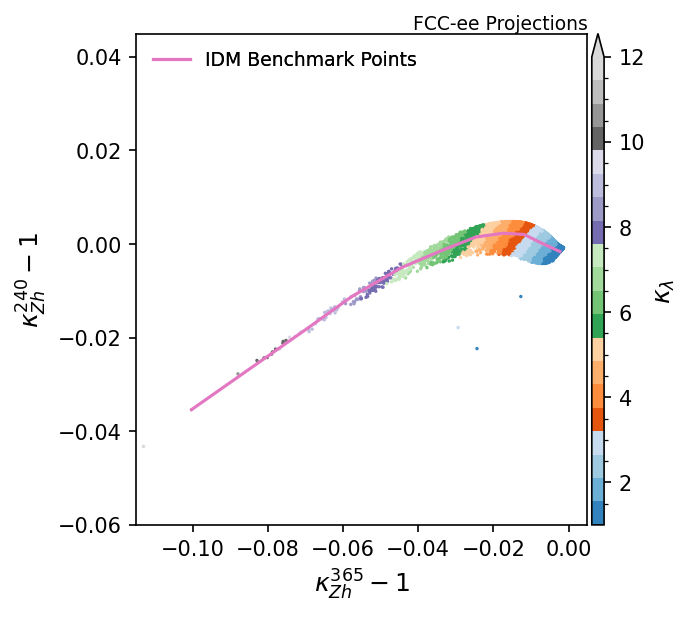

In [31]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': True
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["ZZ_240_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = plot_points_with_WFR[2::2]

legend_locs = ["upper left",]
legend_fontsizes = [9.0,]
markers = [None,]
markersizes = [10,]
color_lines = ["tab:pink",]
label_lines = [r'IDM Benchmark Points',]
legend_cols = [1,]
curves_uncertainty_estimation = ["IDM",]
data_sets = [plot_points_with_WFR,]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [None,]

plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=2
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


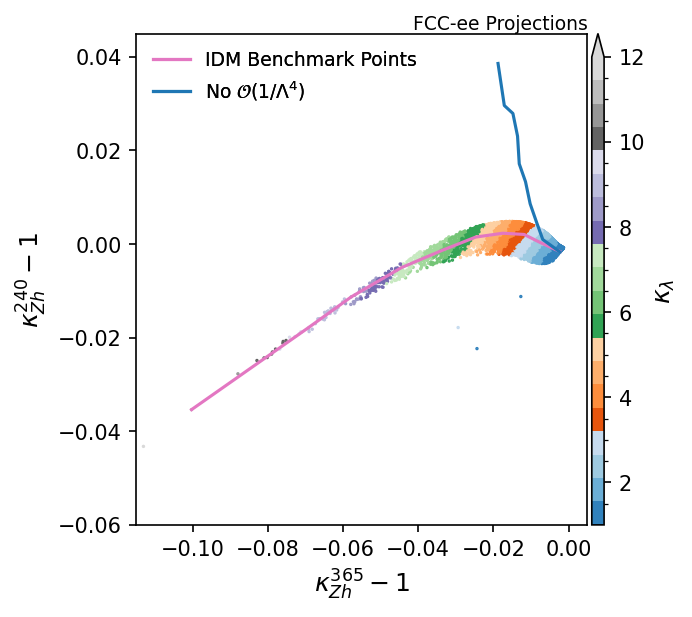

In [32]:
#######################################
### data_with_WFR_ZZh1L_hextlegonly ###
#######################################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': True
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["ZZ_240_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = plot_points_with_WFR[2::2]
# plot_points_with_WFR = plot_points_with_WFR[::-1] 

legend_locs = [None, "upper left",]
legend_cols = [1, 1,]
legend_fontsizes = [9.0, 9.0,]
markers = [None, None,]
markersizes = [10, 10,]
color_lines = ["tab:pink", "tab:blue",]
label_lines = [
    r'IDM Benchmark Points',
    r'No $\mathcal{O}(1/\Lambda^4)$',
]
curves_uncertainty_estimation = ["IDM", "noLoopH3d6Quad",]
data_sets = [
    plot_points_with_WFR, 
    None,
]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad.txt",
]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=3
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


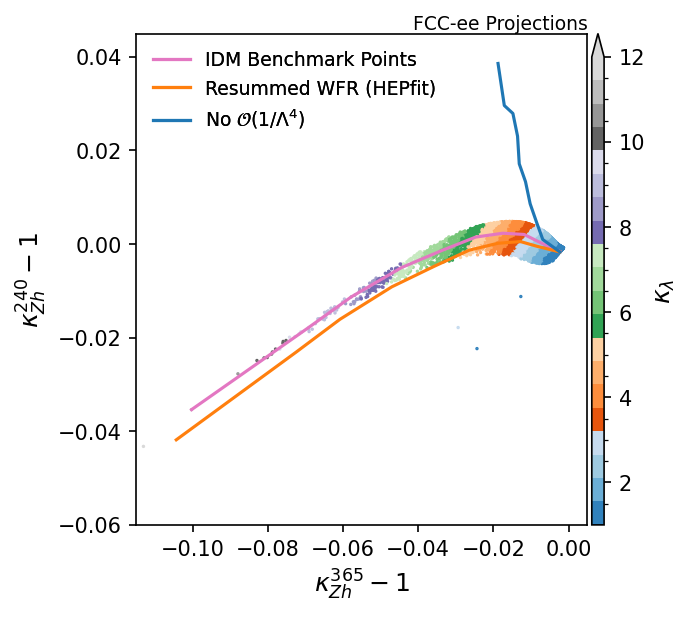

In [33]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': True
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["ZZ_240_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = plot_points_with_WFR[2::2]

legend_locs = [None, None, "upper left",]
legend_cols = [1, 1, 1,]
legend_fontsizes = [9.0, 9.0, 9.0]
markers = [None, None, None,]
markersizes = [10, 10, 10,]
color_lines = [
    "tab:pink",
    "tab:orange",
    "tab:blue",
]
label_lines = [
    r'IDM Benchmark Points',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
]
curves_uncertainty_estimation = [
    "IDM",
    "HEPfit", 
    "noLoopH3d6Quad",
]
data_sets = [
    plot_points_with_WFR,
    None,
    None,
]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs_.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad.txt",
]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=4
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


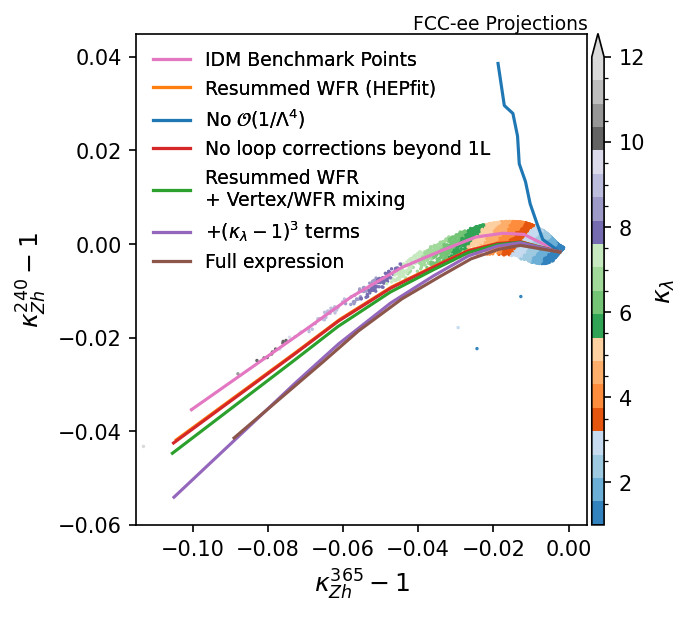

In [34]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': True
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["ZZ_240_with_WFR_ZZh1L_hextlegonly"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = plot_points_with_WFR[2::2]

color_lines = [
    "tab:pink",
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'IDM Benchmark Points',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "IDM",
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [
    plot_points_with_WFR,
    None,
    None,
    None,
    None,
    None,
    None,
]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs_.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Quad_C1term.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Cubi.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Full.txt",
]
n_curves = len(curves_uncertainty_estimation)
legend_locs = [None, None, None, None, None, None, "upper left", ]
legend_fontsizes = [ 9.0 for _ in range(n_curves) ]
markers = [ None for _ in range(n_curves) ]
markersizes = [ 10 for _ in range(n_curves) ]
legend_cols = [1 for _ in range(n_curves)]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(final_xlims)
ax.set_ylim(final_ylims)
plot_name = "Uncertainties_final_plot"; n_plot=5
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

### Estimating uncertainty with ellipses

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


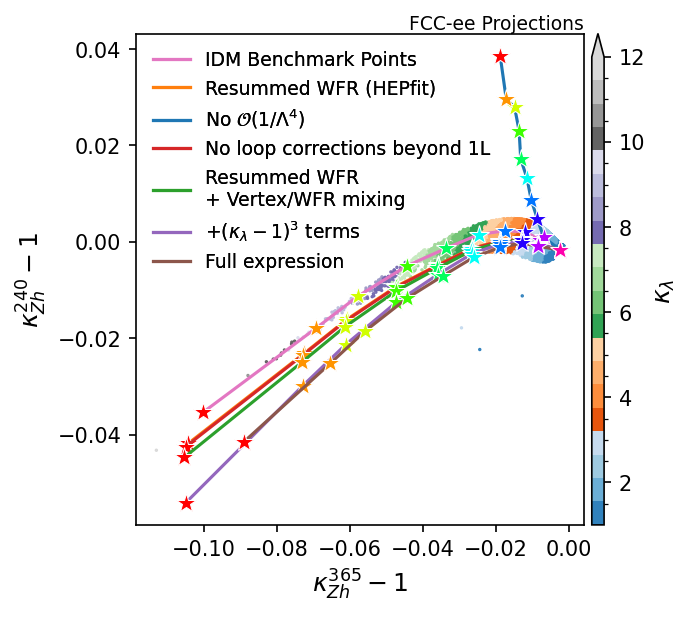

In [35]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': True
                        }
                )

markers = [ "*" for _ in range(n_curves) ]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"uncertainty_with_IDM_WFR_ZZh1L_hextlegonly_BPs.pdf")
plot_name = "Uncertainties_final_plot"; n_plot=6
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


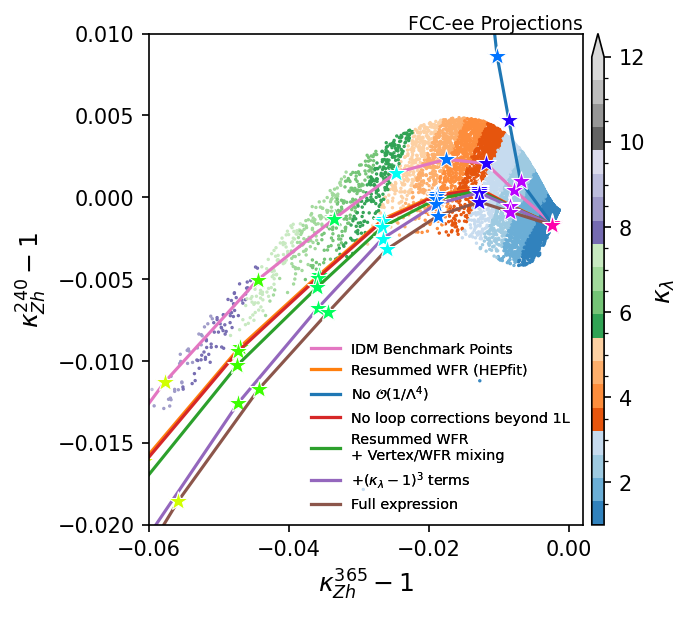

In [36]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': True
                        }
                )
n_curves = 7
legend_locs = [None, None, None, None, None, None, 'lower right']
legend_fontsizes = [6.9 for _ in range(n_curves)]
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"uncertainty_with_IDM_WFR_ZZh1L_hextlegonly_BPs_zoom.pdf")
plot_name = "Uncertainties_final_plot"; n_plot=7
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

## Ellipse patch for matplotlib legend

In [37]:
from matplotlib.patches import Ellipse, Circle
from matplotlib.legend_handler import HandlerPatch

class HandlerEllipse(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        center = 0.5 * width - 0.5 * xdescent, 0.5 * height - 0.5 * ydescent
        p = Ellipse(xy=center, width=1.2*width + xdescent,
                               height=1.2*height + ydescent)
        self.update_prop(p, orig_handle, legend)
        p.set_transform(trans)
        return [p]

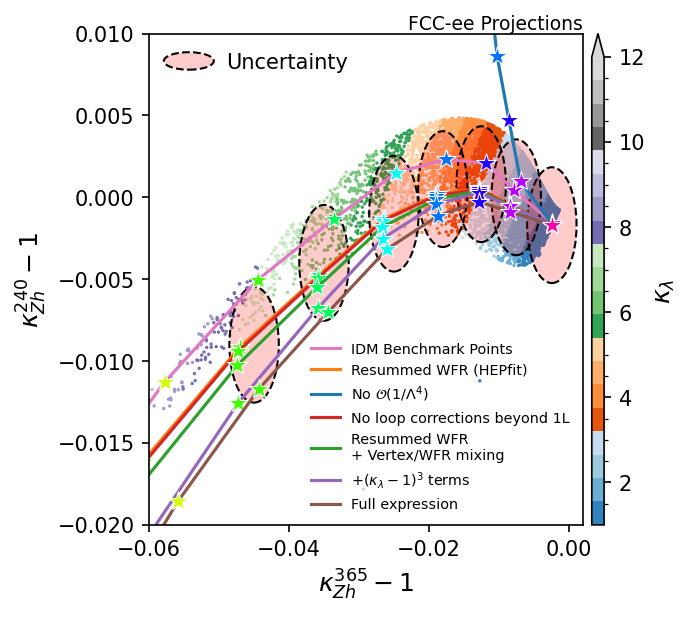

In [38]:
xs     = [-2.4e-3, -0.0075, -0.0125, -0.018, -0.025, -0.035, -0.045, ]
ys     = [-1.7e-3, -0.0e-4, 0.0008,  0.0005, -0.001, -0.004, -0.009, ]
err_xs = [ sqrt(2) * 0.005 / 2. for x in xs]
err_ys = [ sqrt(2) * 0.005 / 2. for x in xs]
black = (0,0,0,1)
red_face = (1,0,0,0.2)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)

ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})

fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"uncertainty_with_IDM_WFR_ZZh1L_hextlegonly_BPs_zoom_ellipses_0.005.pdf")
fig

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


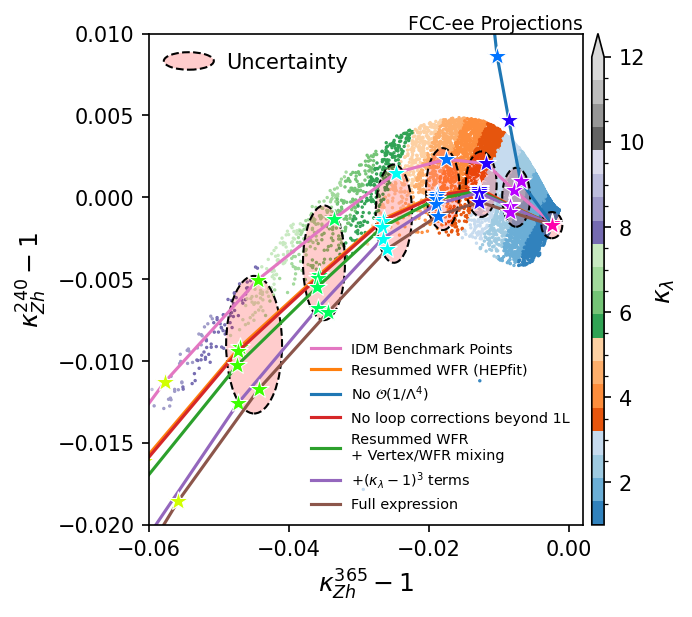

In [39]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': True
                        }
                )

plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)

xs     = [-2.4e-3, -0.0075, -0.0125, -0.018, -0.025, -0.035, -0.045, ]
ys     = [-1.7e-3, -0.0e-4, 0.0008,  0.0005, -0.001, -0.004, -0.009, ]
err_xs = [1.5e-3,  2.0e-3, 2.2e-3,  2.4e-3, 2.6e-3, 3.0e-3, 4e-3,   ]
err_ys = [8.0e-4,  1.8e-3, 2.0e-3,  2.5e-3, 3.0e-3, 3.5e-3, 4.2e-3, ] 
black = (0,0,0,1)
red_face = (1,0,0,0.2)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)

ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"uncertainty_with_IDM_WFR_ZZh1L_hextlegonly_BPs_zoom_ellipses.pdf")
plot_name = "Uncertainties_final_plot"; n_plot = 8
fig.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}.pdf")

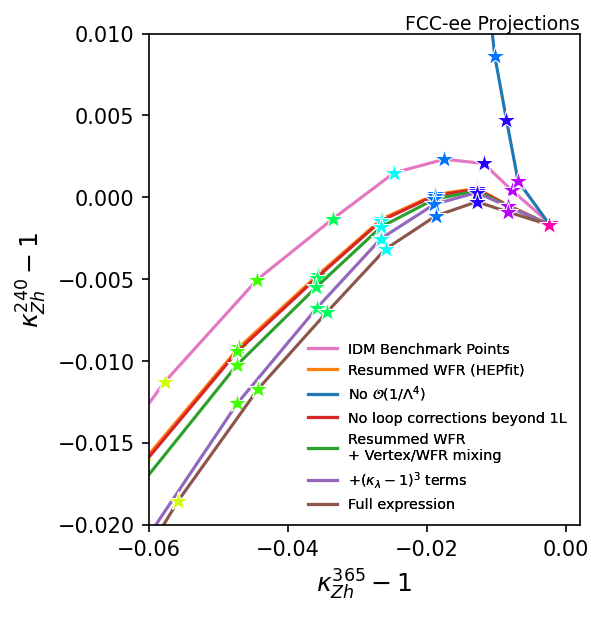

In [40]:
fig, ax = plt.subplots(
    figsize=(3.91, 4.0),
    constrained_layout=True)

ax.set_xlabel(r'$\kappa_{Zh}^{365} - 1$')
ax.set_ylabel(r'$\kappa_{Zh}^{240} - 1$')

text_collider = "FCC-ee Projections"
ax.text(
    1,
    1,
    text_collider,
    horizontalalignment="right",
    verticalalignment="bottom",
    transform=ax.transAxes,
    fontsize=9,
)

legend_locs = [None, None, None, None, None, None, 'lower right',]
legend_fontsizes = [6.9 for _ in range(n_curves)]
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols,
    legend_fontsizes, 
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
plot_name = "Uncertainties_final_plot"; n_plot = 7
plt.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}_alt.pdf")

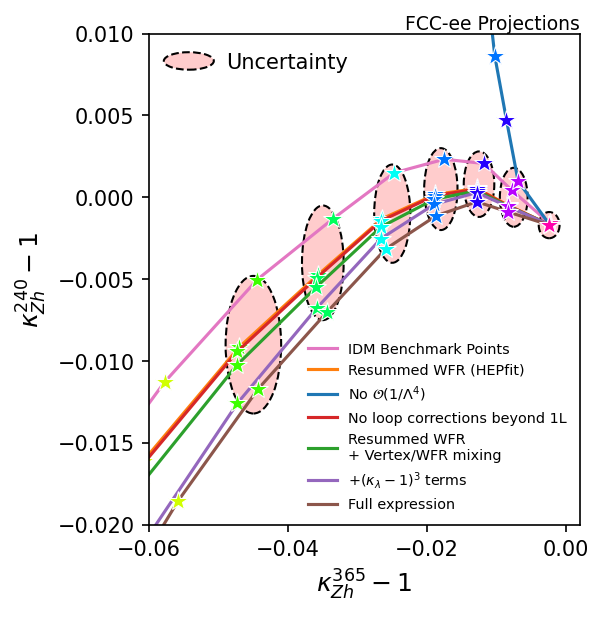

In [41]:
xs     = [-2.4e-3, -0.0075, -0.0125, -0.018, -0.025, -0.035, -0.045, ]
ys     = [-1.7e-3, -0.0e-4, 0.0008,  0.0005, -0.001, -0.004, -0.009, ]
err_xs = [1.5e-3,  2.0e-3, 2.2e-3,  2.4e-3, 2.6e-3, 3.0e-3, 4e-3,   ]
err_ys = [8.0e-4,  1.8e-3, 2.0e-3,  2.5e-3, 3.0e-3, 3.5e-3, 4.2e-3, ] 
black = (0,0,0,1)
red_face = (1,0,0,0.2)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)
    
ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})
plot_name = "Uncertainties_final_plot"; n_plot = 8
fig.savefig(f'{plot_dir}/{plot_name}'+f"_{n_plot}_alt.pdf")
fig

### Using ellipses parameters as estimates for new nuisance parameters

klam = [1.1209067864736006, 2.3867362274064843, 3.3446699219962595, 4.332584967850238, 5.390968560325193, 6.370034303736775, 7.515862276796717]
Mean k_Zh uncertainties: 240: 0.0011625, 365: 0.00115
kappas_Zh_365 = [0.9976925397371732, 0.9922185234979847, 0.9881639572406814, 0.9825134483196111, 0.9752910355098184, 0.9664394848848527, 0.9555670439793632, 0.9422118613961943, 0.930854117220499, 0.8997406285316758]
kappas_Zh_240 = [0.9984072024003215, 1.0004295209531087, 1.002063854015035, 1.0023236553718364, 1.0014989491505055, 0.9986813716599217, 0.9949808105424701, 0.9887204875563975, 0.9821652077679434, 0.9646303586739049]
mean_kappas_Zh = [0.9819894803567036, 1.0019621528457925]
Mean sigma_Zh uncertainties: 240: 0.0023295620053664676, 365: 0.0022585758048204183


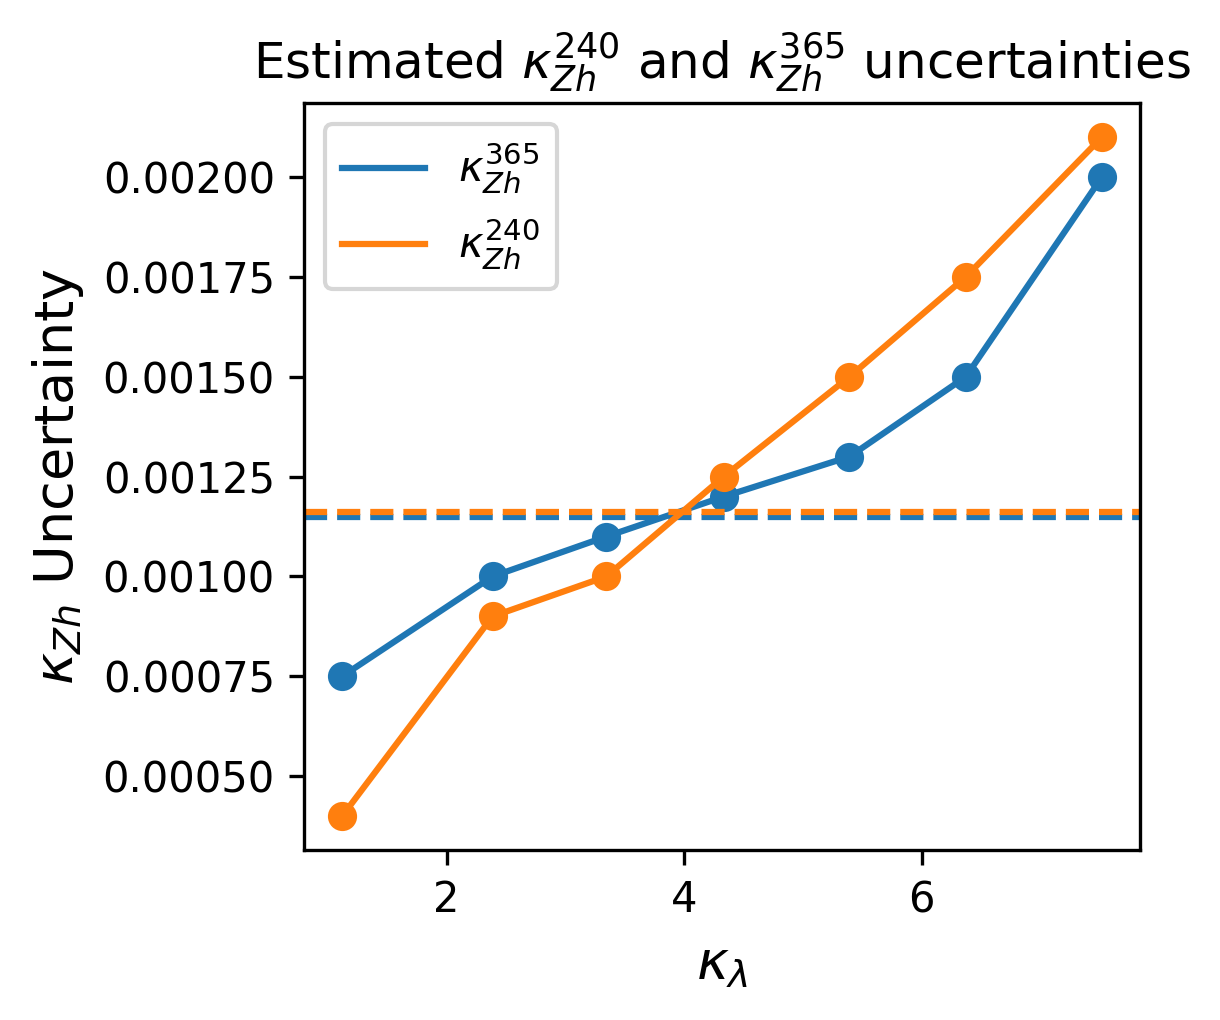

In [42]:
fig, ax = plt.subplots(figsize=(4.0, 3.5), dpi=300)
curves = [0.5*np.array(err_xs), 0.5*np.array(err_ys)]
labels = [r"$\kappa_{Zh}^{365}$", r"$\kappa_{Zh}^{240}$"]
colors = ["tab:blue", "tab:orange",]

mean_uncertainties_kappa = [np.mean(curve[1:5]) for curve in curves]

klam = [ plot_points_with_WFR[i][2] for i in range(len(err_xs)) ]
print(f"klam = {klam}")
for curve, label, color, mean in zip(curves, labels, colors, mean_uncertainties_kappa):
    plt.plot(klam, curve, label=label, color=color)
    plt.scatter(klam, curve, color=color)

    plt.axhline(y=mean, linestyle='--', linewidth=1.5, color=color)
    
plt.xlabel(r"$\kappa_\lambda$", fontsize=13)
plt.title(r"Estimated $\kappa_{Zh}^{240}$ and $\kappa_{Zh}^{365}$ uncertainties")
plt.ylabel(r"$\kappa_{Zh}$ Uncertainty", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}'+"k_ZH_240_365_uncertainties.pdf")

print(f"Mean k_Zh uncertainties: 240: {mean_uncertainties_kappa[1]}, 365: {mean_uncertainties_kappa[0]}")
kappas_Zh_365 = [ (lst[0]+1) for lst in plot_points_with_WFR]
print(f"kappas_Zh_365 = {kappas_Zh_365}")
kappas_Zh_240 = [ (lst[1]+1) for lst in plot_points_with_WFR]
print(f"kappas_Zh_240 = {kappas_Zh_240}")
kappas_Zh = [ kappas_Zh_365[1:5], kappas_Zh_240[1:5]]

mean_kappas_Zh = [np.mean(ks[1:5]) for ks in kappas_Zh]
print(f"mean_kappas_Zh = {mean_kappas_Zh}")
mean_uncertainties_sigma = [2*kappa*mean for kappa, mean in zip(mean_kappas_Zh, mean_uncertainties_kappa)]
print(f"Mean sigma_Zh uncertainties: 240: {mean_uncertainties_sigma[1]}, 365: {mean_uncertainties_sigma[0]}")


# Second set of nuisance parameters: `NP_mismatch`

### Interpolation including more Wilson coefficients

CH_BPs: [ -0.67841313  -4.17826137  -7.03517638  -9.83798517 -12.96716946
 -15.97037203 -19.34209292 -22.65704704 -24.9778176  -31.0277494 ]
CHbox_BPs: [-0.07724434 -0.14578466 -0.18036846 -0.17197327 -0.1497207  -0.10240968
 -0.01493636  0.10468723  0.22605933  0.60072274]
CHD_BPs: [-0.03313977 -0.02012181 -0.02411508 -0.01692248 -0.0210066  -0.02469135
 -0.02137718 -0.02737746 -0.02382377 -0.0241148 ]
CHW_BPs: [0.00339029 0.00481544 0.00707246 0.00747625 0.00898678 0.01058458
 0.01120099 0.01428393 0.01482622 0.01790532]
CHB_BPs: [ 2.18087674e-03  3.36672666e-04 -4.89967657e-05 -1.07859582e-03
 -1.45264352e-03 -1.97646564e-03 -2.97574909e-03 -3.48284773e-03
 -4.19664296e-03 -5.64082970e-03]
CHWB_BPs: [ 0.00458944  0.00111038  0.00134835 -0.00082641 -0.001212   -0.00193137
 -0.00375185 -0.00346872 -0.00519271 -0.00696101]
Sorted indices: [9 8 7 6 5 4 3 2 1 0]


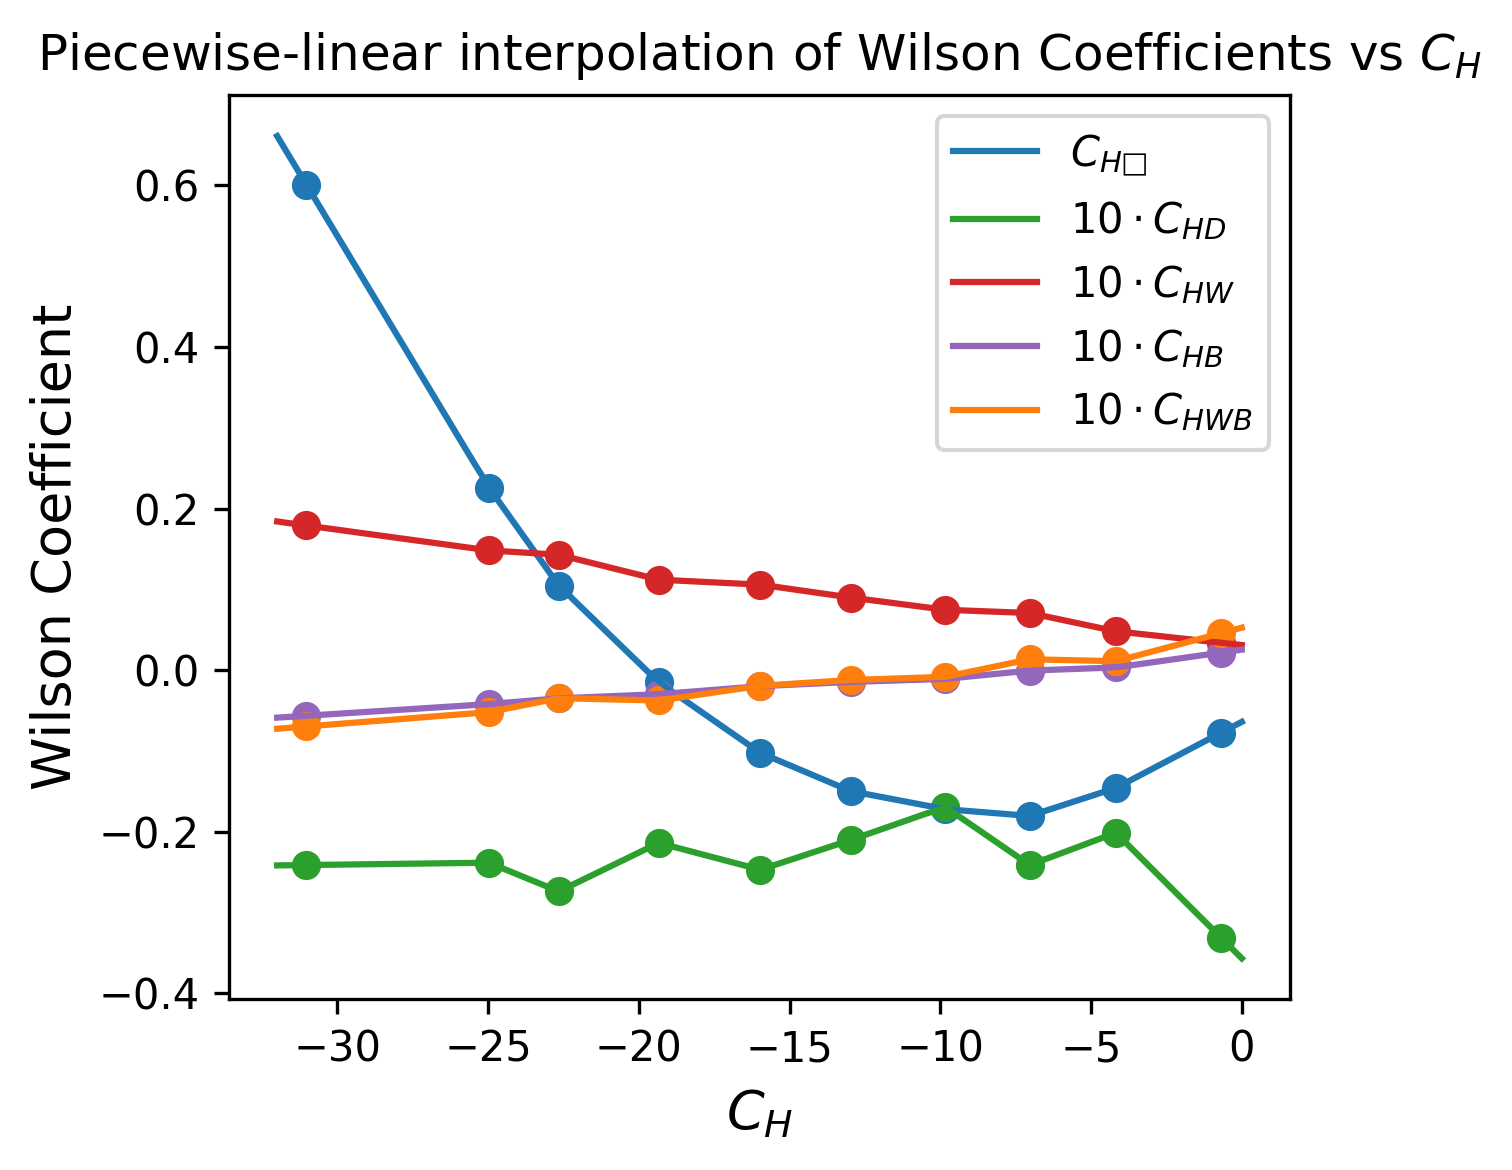

In [43]:
# from scipy.interpolate import CubicSpline
from scipy.interpolate import make_interp_spline

CH_BPs = []
CHbox_BPs = []
CHD_BPs = []
CHW_BPs = []
CHB_BPs = []
CHWB_BPs = []
input_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs/"
with open(f"{input_dir}WC_results.txt", 'r') as f:
    lines = f.readlines()
    for i, line in enumerate(lines):
        if i == 0:  # Skip header line
            continue

        _, CH, CHbox, CHD, CHW, CHB, CHWB = line.split(",")
        CH_BPs.append(float(CH))
        CHbox_BPs.append(float(CHbox))
        CHD_BPs.append(float(CHD))
        CHW_BPs.append(float(CHW))
        CHB_BPs.append(float(CHB))
        CHWB_BPs.append(float(CHWB))

CH_BPs    = np.array(CH_BPs[0::2])
CHbox_BPs = np.array(CHbox_BPs[0::2])
CHD_BPs   = np.array(CHD_BPs[0::2])
CHW_BPs   = np.array(CHW_BPs[0::2])
CHB_BPs   = np.array(CHB_BPs[0::2])
CHWB_BPs  = np.array(CHWB_BPs[0::2])

print(f"CH_BPs: {CH_BPs}")
print(f"CHbox_BPs: {CHbox_BPs}")
print(f"CHD_BPs: {CHD_BPs}")
print(f"CHW_BPs: {CHW_BPs}")
print(f"CHB_BPs: {CHB_BPs}")
print(f"CHWB_BPs: {CHWB_BPs}")

sorted_indices = np.argsort(CH_BPs)
print(f"Sorted indices: {sorted_indices}")
CH_BPs_sorted    = CH_BPs[sorted_indices]
CHbox_BPs_sorted = CHbox_BPs[sorted_indices]
CHD_BPs_sorted   = CHD_BPs[sorted_indices]
CHW_BPs_sorted   = CHW_BPs[sorted_indices]
CHB_BPs_sorted   = CHB_BPs[sorted_indices]
CHWB_BPs_sorted  = CHWB_BPs[sorted_indices]

# print(f"CH values for IDM BPs: {CH_BPs}")
# print(f"CH values for IDM BPs (sorted): {CH_BPs_sorted}")
# print(f"CHbox values for IDM BPs: {CHbox_BPs}")
# print(f"CHbox values for IDM BPs (sorted): {CHbox_BPs_sorted}")
spline_degree = 1  # Linear interpolation
CH_CHbox_interpolator = make_interp_spline(CH_BPs_sorted, CHbox_BPs_sorted, k=spline_degree)
CH_CHD_interpolator   = make_interp_spline(CH_BPs_sorted, CHD_BPs_sorted,   k=spline_degree)
CH_CHW_interpolator   = make_interp_spline(CH_BPs_sorted, CHW_BPs_sorted,   k=spline_degree)
CH_CHB_interpolator   = make_interp_spline(CH_BPs_sorted, CHB_BPs_sorted,   k=spline_degree)
CH_CHWB_interpolator  = make_interp_spline(CH_BPs_sorted, CHWB_BPs_sorted,  k=spline_degree)

CH_curve = np.linspace(-32, 0, 50)
CHbox_curve = CH_CHbox_interpolator(CH_curve)
CHD_curve   = CH_CHD_interpolator(CH_curve)
CHW_curve   = CH_CHW_interpolator(CH_curve)
CHB_curve   = CH_CHB_interpolator(CH_curve)
CHWB_curve  = CH_CHWB_interpolator(CH_curve)
# print(f"CH curve: {CH_curve}")
# print(f"CHbox curve: {CHbox_curve}")

WC_curves_plot = [CHbox_curve, 10*CHD_curve, 10*CHW_curve, 10*CHB_curve, 10*CHWB_curve]
WC_BPs_plot = [CHbox_BPs, 10*CHD_BPs, 10*CHW_BPs, 10*CHB_BPs, 10*CHWB_BPs]
WC_tex_labels = ["$C_{H\u25A1}$", r"$10\cdot C_{HD}$", r"$10\cdot C_{HW}$", r"$10\cdot C_{HB}$", r"$10\cdot C_{HWB}$"]
colors = ["tab:blue", "tab:green", "tab:red", "tab:purple", "tab:orange"]

fig, ax = plt.subplots(figsize=(4.5, 4.),dpi=300)

for WC_curve, WC_BP, tex_label, color in zip(WC_curves_plot, WC_BPs_plot, WC_tex_labels, colors):
    # plt.plot(CH_curve, WC_curve, label=r"Interpolated curve "+tex_label, color=color)
    plt.plot(CH_curve, WC_curve, label=tex_label, color=color)
    plt.scatter(CH_BPs, WC_BP, color=color)
    
plot_name = "IDM_results_k_ZH_240_vs_365"
plt.xlabel(r"$C_{H}$", fontsize=13)
plt.title(r"Piecewise-linear interpolation of Wilson Coefficients vs $C_{H}$")
plt.ylabel(r"Wilson Coefficient", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}'+"_WCs_linear_interpolation.pdf")

WC_curves = [CHbox_curve, CHD_curve, CHW_curve, CHB_curve, CHWB_curve]
WC_BPs = [CHbox_BPs, CHD_BPs, CHW_BPs, CHB_BPs, CHWB_BPs]

output_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs"
with open(f"{output_dir}/WC_interpolator_results.txt", "w") as f:
    print(f"CH,CHbox,CHD,CHW,CHB,CHWB", file=f)
    for i in range(len(CH_curve)):
        f.write(f"{CH_curve[i]},{CHbox_curve[i]},{CHD_curve[i]},{CHW_curve[i]},{CHB_curve[i]},{CHWB_curve[i]}\n")

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


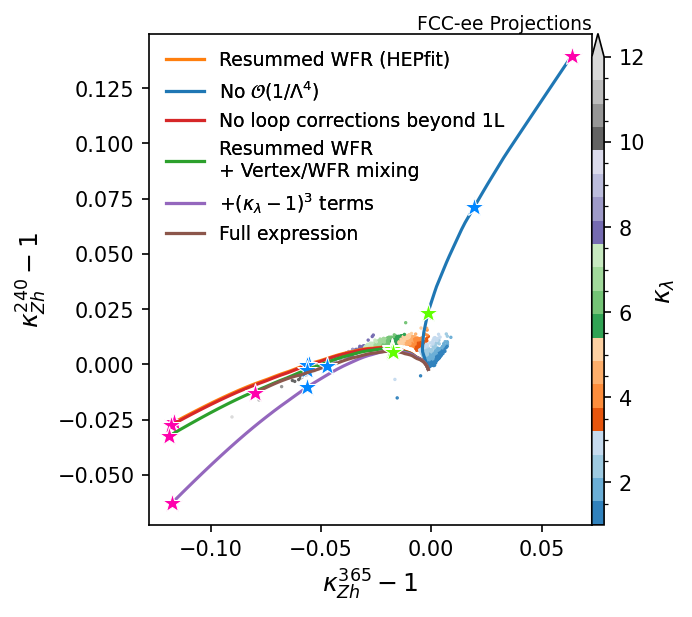

In [44]:
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs/comparison_plots"
plot_name = "IDM_results_k_ZH_240_vs_365"
plot_name_suffix = "_with_self_consistent_curves_SMEFT_formula"
k_ZH_240_365_predictions_file_names_all_WCs = [
    f"{results_directory}/k_ZH_240_365_predictions.txt",
    f"{results_directory}/k_ZH_240_365_predictions_noLoopH3d6Quad.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopHd6NoSubleading.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Quad_C1term.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Cubi.txt",
    f"{results_directory}/k_ZH_240_365_predictions_LoopH3d6Full.txt",
]
n_curves = len(k_ZH_240_365_predictions_file_names_all_WCs)

legend_locs = [None, None, None, None, None, "upper left",]
legend_cols = [1 for _ in range(n_curves)]
legend_fontsizes = [9.0 for _ in range(n_curves)]
markers = ["*" for _ in range(n_curves)]
markersizes = [10 for _ in range(n_curves)]
color_lines = [
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [
    None,
    None,
    None,
    None,
    None,
    None,
]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM_vertex': False,
                        }
                )
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names_all_WCs, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    max_n_markers=3,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_all_WCs_markers.pdf")


Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


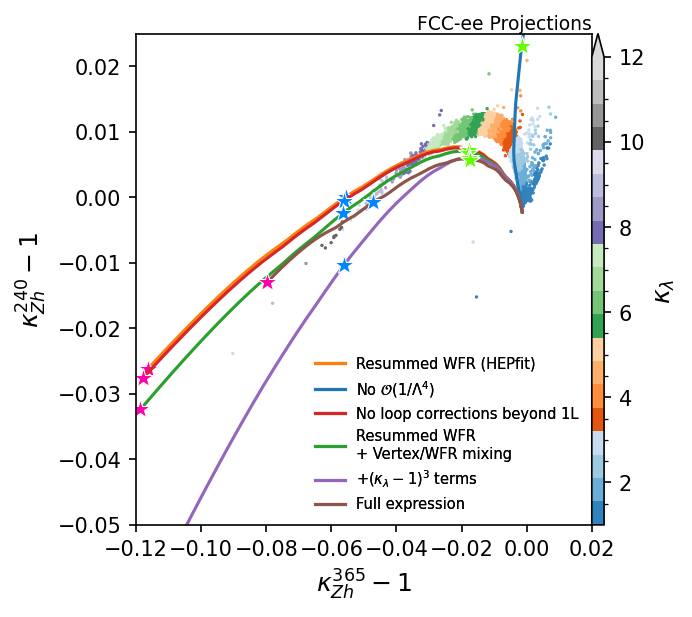

In [45]:
n_curves = 6
legend_locs = [None, None, None, None, None, "lower right",]
legend_fontsizes = [7.0 for _ in range(n_curves)]
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM_vertex': False,
                        }
                )
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names_all_WCs, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    max_n_markers=3,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
)
ax.set_xlim(-0.12, +0.02)
ax.set_ylim(-0.050, +0.025)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_comparison_uncertainty_estimation_all_WCs_markers_zoom.pdf")


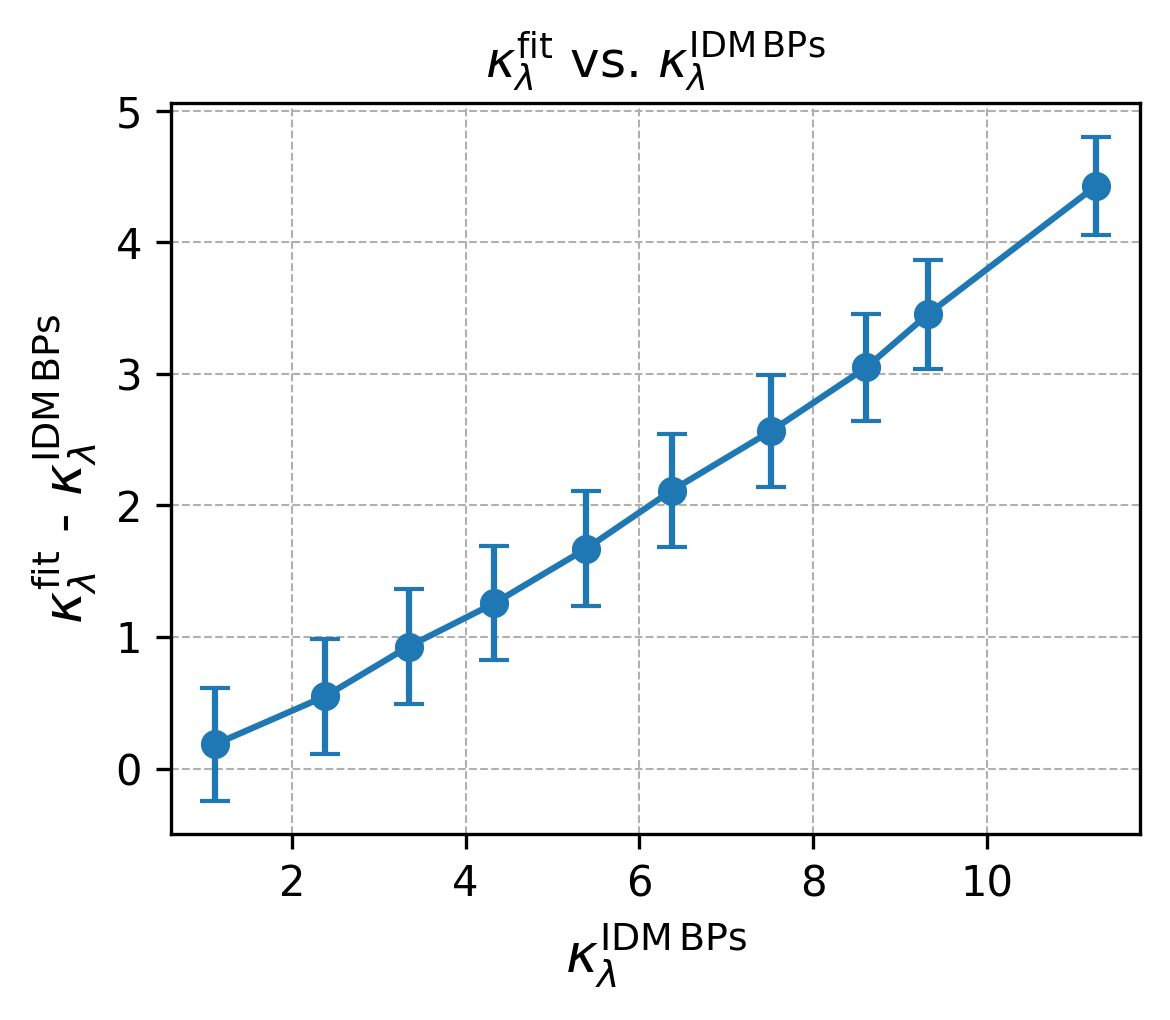

In [46]:
klam_BPs = np.array([BP["lam"] for BP in bp_kappas])
klam_BPs = klam_BPs[2::2]
# k_ZH_240_BPs = [BP["ZZ_240_with_WFR_ZZh1L_hextlegonly"] for BP in bp_kappas]
# k_ZH_365_BPs = [BP["ZZ_365_with_WFR_ZZh1L_hextlegonly"] for BP in bp_kappas]

klam_fits = []
klam_fits_errors = []
input_dir = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Fits_HLLHC_FCCee/different_BPs/comparison_plots/results_fits_realistic_HL_LHC_WFR_kala2_input_all_small_priors_long"
with open(f"{input_dir}/klam_results.txt", 'r') as f:
    lines = f.readlines()
    for i, line in enumerate(lines):
        if i == 0:  # Skip header line
            continue

        BP, klam, klam_error = line.split(",")
        klam_fits.append(float(klam))
        klam_fits_errors.append(float(klam_error))

klam_fits = np.array(klam_fits[::2])
klam_fits_errors = np.array(klam_fits_errors[::2])

spline_degree = 1  # Linear interpolation
klam_interpolator = make_interp_spline(klam_BPs, klam_fits, k=spline_degree)

# klam_curve = np.linspace(-32, 0, 50)

delta_klam = klam_fits - klam_BPs
color = "tab:blue"
plt.subplots(figsize=(4.0, 3.5), dpi=300)
plt.plot(klam_BPs, delta_klam, color=color)
plt.errorbar(klam_BPs, delta_klam, yerr=klam_fits_errors, fmt='o', capsize=3.5, color=color)
    
plt.xlabel(r"$\kappa_\lambda^{\mathrm{IDM\/BPs}}$", fontsize=13)
plt.ylabel(r"$\kappa_\lambda^{\mathrm{fit}}$ - $\kappa_\lambda^{\mathrm{IDM\/BPs}}$", fontsize=13)
plt.title(r"$\kappa_\lambda^{\mathrm{fit}}$ vs. $\kappa_\lambda^{\mathrm{IDM\/BPs}}$")
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}'+"k_ZH_240_365_uncertainties_klam_fit_vs_IDM.pdf")

Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


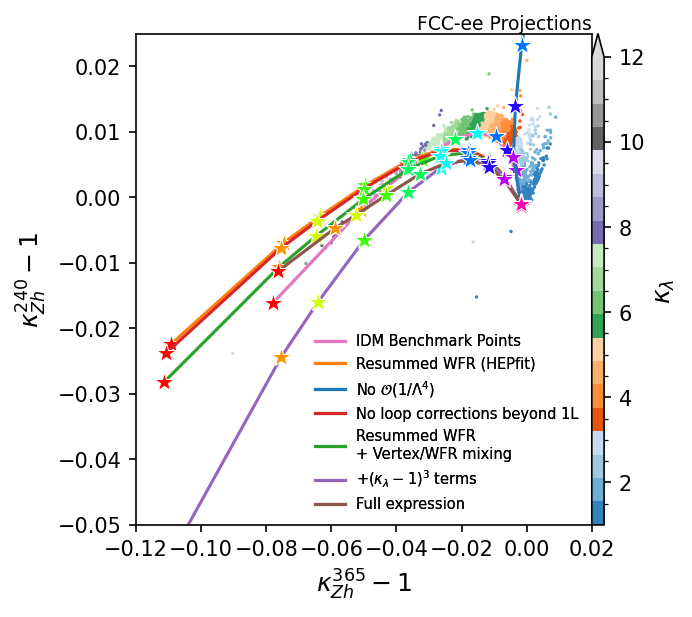

In [47]:
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs/comparison_plots"
flags = ["", "_noLoopH3d6Quad", "_LoopHd6NoSubleading", "_LoopH3d6Quad_C1term", "_LoopH3d6Cubi", "_LoopH3d6Full"]
for flag in flags:
    with open(f"{results_directory}/k_ZH_240_365_predictions_BPs_{flag}.txt", 'r') as input_file:
        with open(f"{results_directory}/k_ZH_240_365_predictions_BPs_{flag}_even.txt", 'w') as output_file:
            lines = input_file.readlines()
            for idx, line in enumerate(lines):
                if idx % 4 == 0 or idx % 4 == 1:
                    output_file.write(line)


k_ZH_240_365_predictions_file_names_all_WCs = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs__even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad_even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading_even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Quad_C1term_even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Cubi_even.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Full_even.txt",
]
n_curves = len(k_ZH_240_365_predictions_file_names_all_WCs)

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR"] - 1,
     BP["ZZ_240_with_WFR"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = plot_points_with_WFR[2::2]

legend_locs = [None, None, None, None, None, None, "lower right",]
legend_cols = [1 for _ in range(n_curves)]
legend_fontsizes = [7.0 for _ in range(n_curves)]
markers = ["*" for _ in range(n_curves)]
markersizes = [10 for _ in range(n_curves)]
color_lines = [
    "tab:pink",
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'IDM Benchmark Points',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "IDM",
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [
    plot_points_with_WFR,
    None,
    None,
    None,
    None,
    None,
    None,
]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM_vertex': False,
                        }
                )
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names_all_WCs, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(-0.12, +0.02)
ax.set_ylim(-0.050, +0.025)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_uncertainty_all_WCs_with_IDM_WFR_BPs_zoom.pdf")


Processing data files: ['data/IDM/allIDMpoints_2025-01-14', 'data/IDM/outlierIDMpoints_2025-01-17', 'data/IDM/outlierIDMpoints2_2025-01-17', 'data/IDM/outlierIDMpoints3_2025-01-17', 'data/IDM/outlierIDMpoints4_2025-01-17']


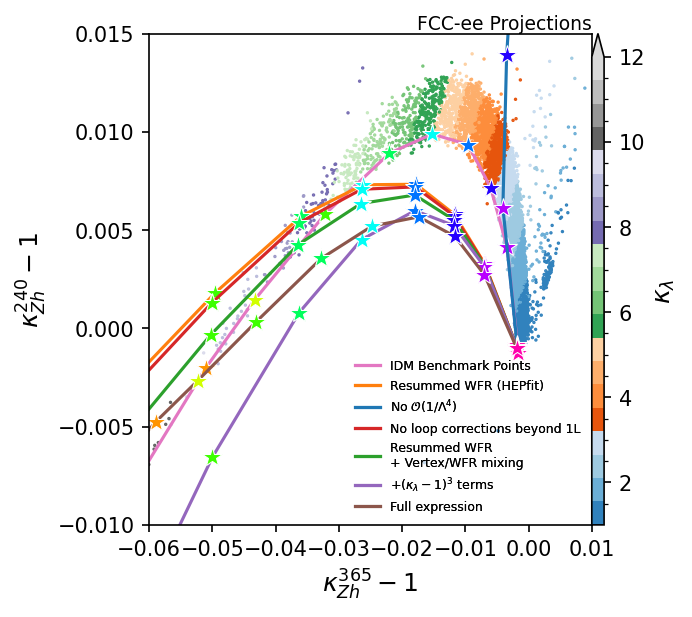

In [48]:
n_curves = 7
legend_locs = [None, None, None, None, None, None, "lower right",]
legend_fontsizes = [ 6.0 for _ in range(n_curves) ]
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': True,
                            'data_with_WFR_no_BSM_vertex': False,
                        }
                )
plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names_all_WCs, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
ax.set_xlim(-0.06, +0.01)
ax.set_ylim(-0.010, +0.015)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_uncertainty_all_WCs_with_IDM_WFR_BPs_zoom2.pdf")

Processing file: /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs/comparison_plots/k_ZH_240_365_predictions_BPs__even.txt
[0.9990554595048612, 1.0032882084333903, 1.0057934192133393, 1.0073297694563659, 1.0073045106360168, 1.0057118064899806, 1.0018205093246724, 0.9971125167833784, 0.9930381690598447, 0.9775456204878801]
Processing file: /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs/comparison_plots/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad_even.txt
[0.9991270679307822, 1.0061392522007802, 1.013891481867508, 1.0231766600502017, 1.0348053419477665, 1.0473685043589105, 1.0628417365640555, 1.080663542671499, 1.0944510574066586, 1.133515893777663]
Processing file: /cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/all_WCs/comparison_plots/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading_even.txt
[0.9990541812335461, 1.0032615651237649, 1.005722849852799, 1.007195480366

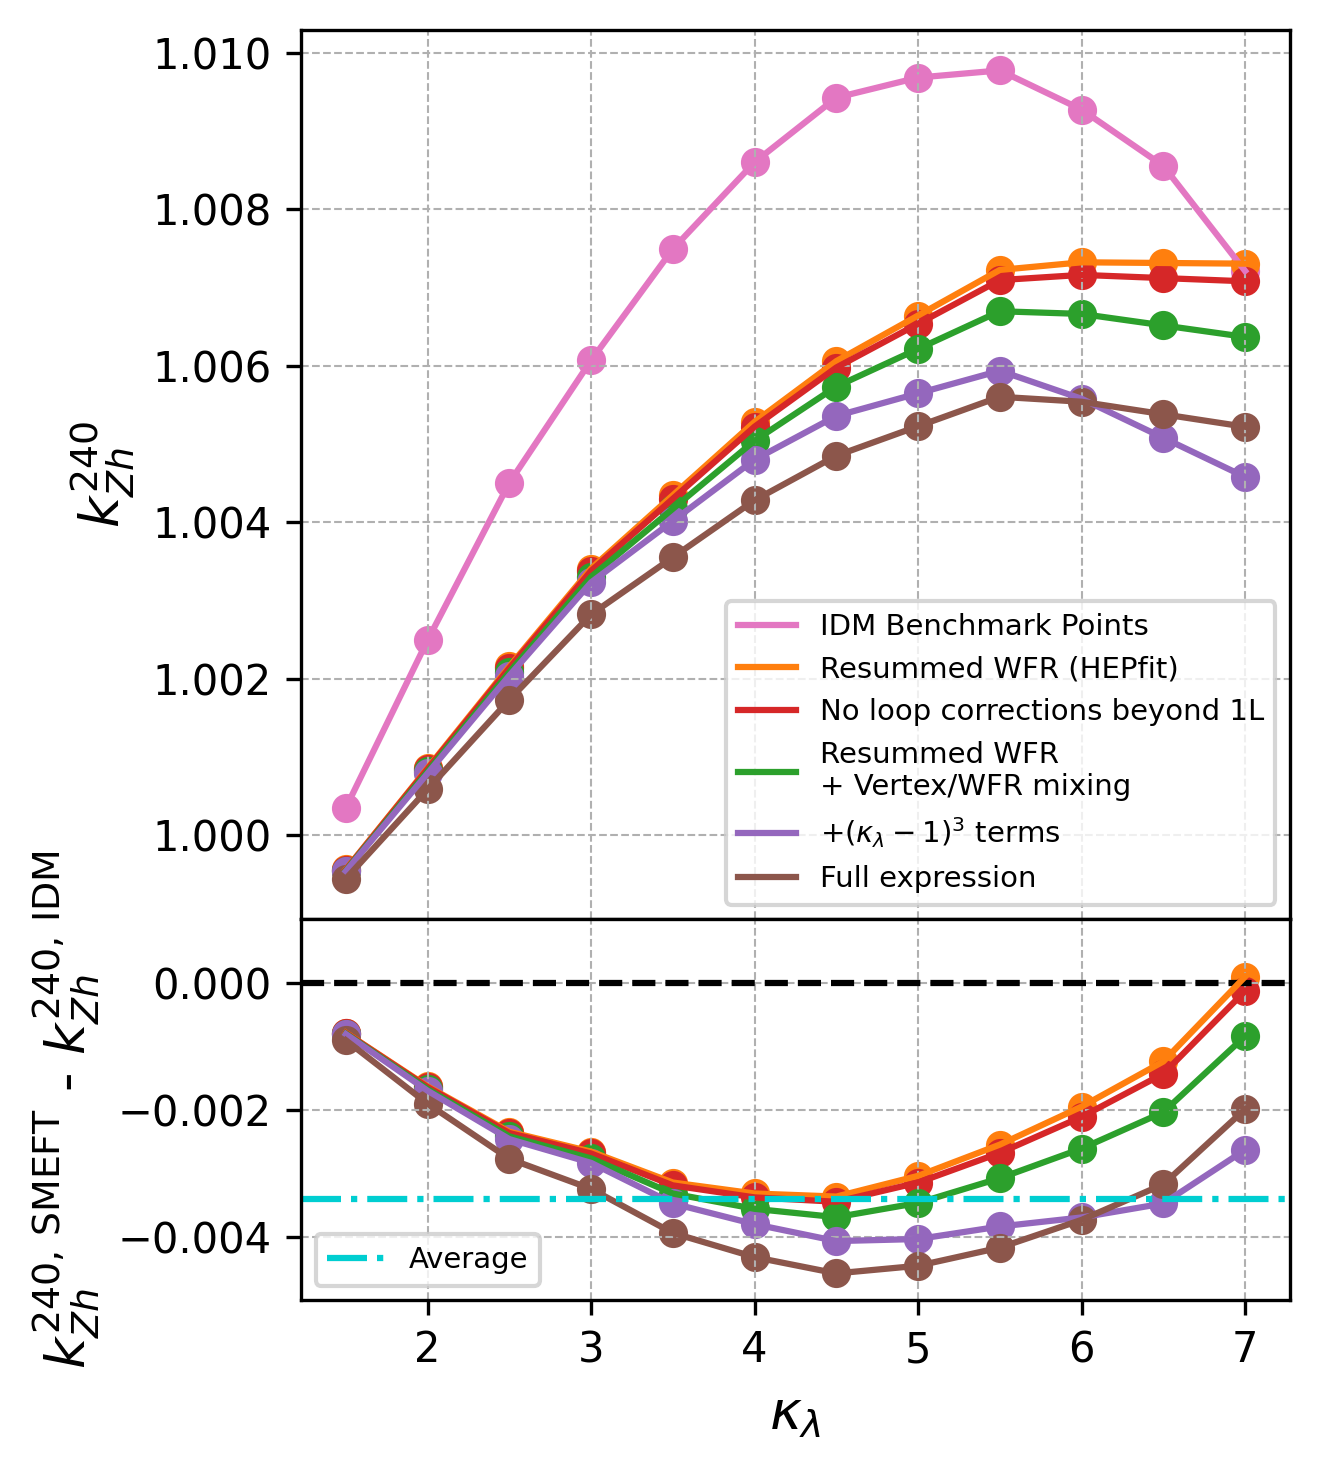

In [49]:
spline_degree = 1  # Linear interpolation
interpolators = {}
# klam_points = np.array([1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
klam_points = np.linspace(1.5, 7.0, 12)

interpolations = {}
for flag in flags:
    interpolators[flag] = {}
    interpolations[flag] = {}
    file_name = f"{results_directory}/k_ZH_240_365_predictions_BPs_{flag}_even.txt"
    print(f"Processing file: {file_name}")
    k_ZH_240_values = []
    k_ZH_365_values = []
    with open(file_name, "r") as self_consistent_results_file:
        lines = self_consistent_results_file.readlines()
        for n, line in enumerate(lines):
            columns = line.split()

            if columns[-2].startswith("eeZH_FCCee240"):
                k_ZH_240_values.append(np.sqrt(float(columns[-1])))
            elif columns[-2].startswith("eeZH_FCCee365"):
                k_ZH_365_values.append(np.sqrt(float(columns[-1])))
        print(k_ZH_240_values)
    interpolators[flag]["k_ZH_240"] = make_interp_spline(klam_fits, k_ZH_240_values, k=spline_degree)
    interpolators[flag]["k_ZH_365"] = make_interp_spline(klam_fits, k_ZH_365_values, k=spline_degree)

    interpolations[flag]["k_ZH_240"] = interpolators[flag]["k_ZH_240"](klam_points)
    interpolations[flag]["k_ZH_365"] = interpolators[flag]["k_ZH_365"](klam_points)

k_ZH_240_BPs = [BP["ZZ_240_with_WFR"] for BP in bp_kappas]
k_ZH_365_BPs = [BP["ZZ_365_with_WFR"] for BP in bp_kappas]
k_ZH_240_BPs = np.array(k_ZH_240_BPs[2::2])
k_ZH_365_BPs = np.array(k_ZH_365_BPs[2::2])
IDM_interpolator_k_ZH_240 = make_interp_spline(klam_BPs, k_ZH_240_BPs, k=spline_degree)
IDM_interpolator_k_ZH_365 = make_interp_spline(klam_BPs, k_ZH_365_BPs, k=spline_degree)
IDM_interpolation_k_ZH_240 = IDM_interpolator_k_ZH_240(klam_points)
IDM_interpolation_k_ZH_365 = IDM_interpolator_k_ZH_365(klam_points)

# fig, ax = plt.subplots(figsize=(4.0, 3.5), dpi=300)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(4.5, 5), height_ratios=[0.7, 0.3], dpi=300, gridspec_kw=dict(hspace=0.))

flag_colors = ["tab:orange", "tab:blue", "tab:red", "tab:green", "tab:purple", "tab:brown"]
flag_labels = [
    # r'IDM Benchmark Points',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax1.plot(klam_points, IDM_interpolation_k_ZH_240, label=r'IDM Benchmark Points', color="tab:pink")
ax1.scatter(klam_points, IDM_interpolation_k_ZH_240, color="tab:pink")
for idx, (flag, color, label) in enumerate(zip(flags, flag_colors, flag_labels)):
    if flag == "_noLoopH3d6Quad":
        continue
    ax1.plot(klam_points, interpolations[flag]["k_ZH_240"], label=label, color=color)
    ax1.scatter(klam_points, interpolations[flag]["k_ZH_240"], color=color)

    ax2.plot(klam_points, interpolations[flag]["k_ZH_240"] - IDM_interpolation_k_ZH_240, color=color)
    ax2.scatter(klam_points, interpolations[flag]["k_ZH_240"] - IDM_interpolation_k_ZH_240, color=color)
    # plt.plot(klam_points, interpolations[flag]["k_ZH_365"], label=f"k_ZH_365 {flag}", color="tab:orange")

ax2.set_xlabel(r"$\kappa_\lambda$", fontsize=13)
ax1.set_ylabel(r"$k_{Zh}^{240}$", fontsize=13)
ax2.set_ylabel(r"$k_{Zh}^{240,\/\mathrm{SMEFT}}$ - $k_{Zh}^{240,\/\mathrm{IDM}}$", fontsize=13)
# plt.title(r"$k_{Zh}^{240}$ vs. $\kappa_\lambda$ for different flags")
ax1.grid(which='both', linestyle='--', linewidth=0.5)
ax2.grid(which='both', linestyle='--', linewidth=0.5)
ax1.legend(fontsize=7.0, loc='lower right')
ax2.set_ylim(-0.005, 0.001)

# Obtaining uncertainty estimate:
err_estimate = []
for idx, klam in enumerate(klam_points[:-2]):
    flags_for_error = [flag for flag in flags if flag != "_noLoopH3d6Quad" ]
    diffs = [interpolations[flag]["k_ZH_240"][idx] - IDM_interpolation_k_ZH_240[idx] for flag in flags_for_error]
    err_estimate.append( np.max( np.abs(diffs) ) )
print(f"Maximum errors: {err_estimate}")
k_Zh_240_err = np.mean(err_estimate)
print(f"k_Zh_240 uncertainty estimate: {k_Zh_240_err}")
print(f"sigma_Zh_240 uncertainty estimate: {2 * (np.mean(IDM_interpolation_k_ZH_240)) * k_Zh_240_err}")
ax2.axhline(-k_Zh_240_err, color='darkturquoise', linestyle='-.', linewidth=1.5, label="Average")
ax2.legend(fontsize=7.0, loc='best')

plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_k_ZH_240_vs_kappa_lambda_all_WCs.pdf")

Maximum errors: [0.000334002745037143, 0.0011927408238858739, 0.001905300290698575, 0.0021423301483479706, 0.0024603081046734587, 0.002474093435301694, 0.002432594834000601, 0.002085621167978946, 0.0015745402253083407, 0.0009166531117026366]
k_Zh_365 uncertainty estimate: 0.001751818488693524
sigma_Zh_365 uncertainty estimate: 0.0034632124670086065


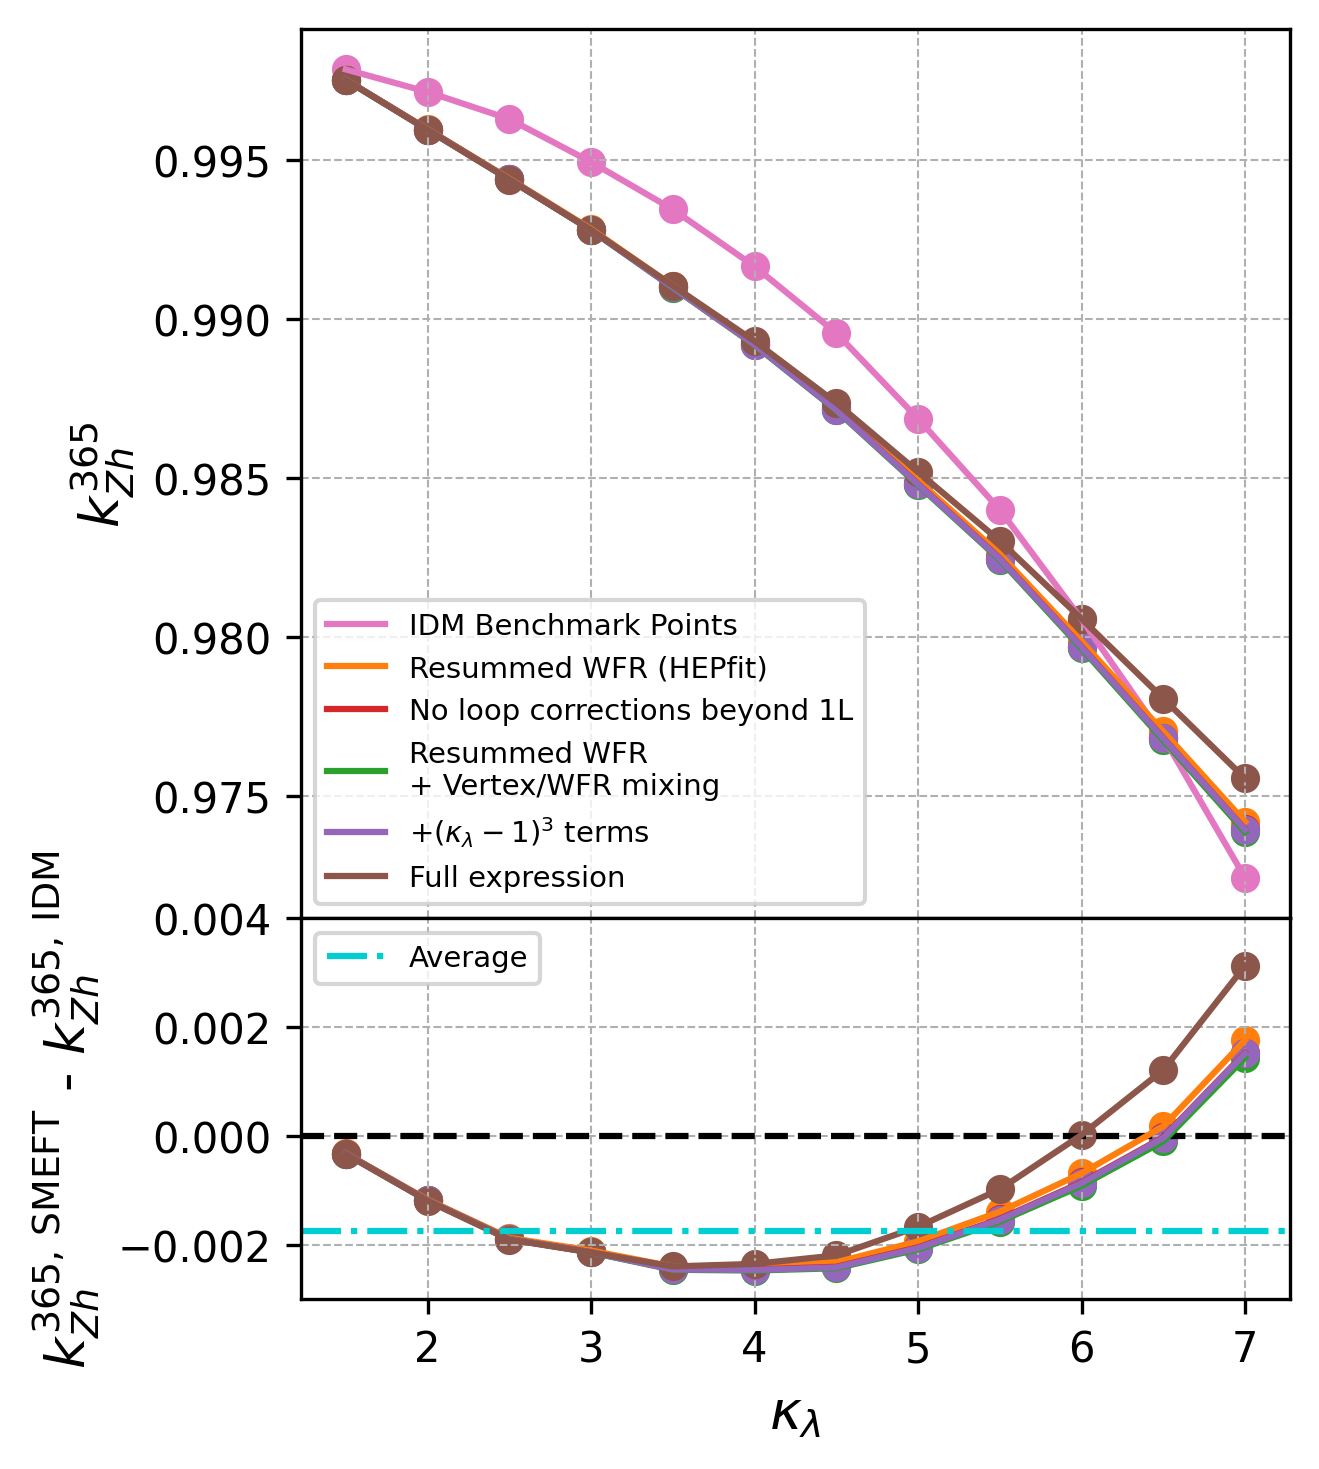

In [50]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(4.5, 5), height_ratios=[0.7, 0.3], dpi=300, gridspec_kw=dict(hspace=0.))

ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax1.plot(klam_points, IDM_interpolation_k_ZH_365, label=r'IDM Benchmark Points', color="tab:pink")
ax1.scatter(klam_points, IDM_interpolation_k_ZH_365, color="tab:pink")
for idx, (flag, color, label) in enumerate(zip(flags, flag_colors, flag_labels)):
    if flag == "_noLoopH3d6Quad":
        continue
    ax1.plot(klam_points, interpolations[flag]["k_ZH_365"], label=label, color=color)
    ax1.scatter(klam_points, interpolations[flag]["k_ZH_365"], color=color)

    ax2.plot(klam_points, interpolations[flag]["k_ZH_365"] - IDM_interpolation_k_ZH_365, color=color)
    ax2.scatter(klam_points, interpolations[flag]["k_ZH_365"] - IDM_interpolation_k_ZH_365, color=color)
    # plt.plot(klam_points, interpolations[flag]["k_ZH_365"], label=f"k_ZH_365 {flag}", color="tab:orange")

ax2.set_xlabel(r"$\kappa_\lambda$", fontsize=13)
ax1.set_ylabel(r"$k_{Zh}^{365}$", fontsize=13)
ax2.set_ylabel(r"$k_{Zh}^{365,\/\mathrm{SMEFT}}$ - $k_{Zh}^{365,\/\mathrm{IDM}}$", fontsize=13)
# plt.title(r"$k_{Zh}^{365}$ vs. $\kappa_\lambda$ for different flags")
ax1.grid(which='both', linestyle='--', linewidth=0.5)
ax2.grid(which='both', linestyle='--', linewidth=0.5)
ax1.legend(fontsize=7.0, loc='lower left')
ax2.set_ylim(-0.003, 0.004)

# Obtaining uncertainty estimate:
err_estimate = []
for idx, klam in enumerate(klam_points[:-2]):
    flags_for_error = [flag for flag in flags if flag != "_noLoopH3d6Quad" ]
    diffs = [interpolations[flag]["k_ZH_365"][idx] - IDM_interpolation_k_ZH_365[idx] for flag in flags_for_error]
    err_estimate.append( np.max( np.abs(diffs) ) )
print(f"Maximum errors: {err_estimate}")
k_Zh_365_err = np.mean(err_estimate)
print(f"k_Zh_365 uncertainty estimate: {k_Zh_365_err}")
print(f"sigma_Zh_365 uncertainty estimate: {2 * (np.mean(IDM_interpolation_k_ZH_365)) * k_Zh_365_err}")
ax2.axhline(-k_Zh_365_err, color='darkturquoise', linestyle='-.', linewidth=1.5, label="Average")
ax2.legend(fontsize=7.0, loc='best')

plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_k_ZH_365_vs_kappa_lambda_all_WCs.pdf")


## Finding BP with $\kappa_\lambda \approx 1$

In [69]:
from utils.common_utils import find_benchmark_lambda1

BR_constraints=0.05
data_file="data/IDM/allIDMpoints_2025-01-14"
df = pd.read_csv(data_file + ".csv")

df = df.replace("", np.nan)
df = df.dropna()
old_df_indices = df.index.to_numpy()
df = df.reset_index(drop=True)
n_pts = df.shape[0]

kappas, EWPOs, model_pars = read_IDM_file(df)

output_dir = "./scan_output/IDM_scan_output"
subprocess.run(["mkdir", "-p", output_dir])

BP_filename = f"{output_dir}/Benchmark_Points_lambda1.txt"
BR_constraint=0.05

BP_Name = "BP_lambda1"

bp_klam1_kappas, bp_klam1_EWPOs, bp_klam1_model_pars, _ = find_benchmark_lambda1(
    n_pts=n_pts,
    kappas=kappas,
    EWPOs=EWPOs,
    model_pars=model_pars,
    old_df_indices=old_df_indices,
    BP_Name=BP_Name,
    BR_constraints=BR_constraints,
)
# print(bp_klam1_kappas)


elif BP == "BP_lambda1":
    kappas['uu'] = 0.9984178113049657
    kappas['dd'] = 0.9984178113049657
    kappas['ss'] = 0.9984178113049657
    kappas['cc'] = 0.9984178113049657
    kappas['bb'] = 0.9984178113049657
    kappas['tt'] = 0.9984178113049657
    kappas['ee'] = 0.9984178113049657
    kappas['mumu'] = 0.9984178113049657
    kappas['tautau'] = 0.9984178113049657
    kappas['ZZ_0'] = 0.9991982973881574
    kappas['ZZ_240'] = 0.9998186516447237
    kappas['ZZ_365'] = 0.999375887226692
    kappas['ZZ_500'] = 0.9993603116685574
    kappas['ZZ_550'] = 0.9994021868768549
    kappas['ZZ'] = 0.9983808715093025
    kappas['WW'] = 0.9983808715093025
    kappas['lam'] = 1.1000242642433875
    kappas['gamgam'] = 0.9919985602913337
    kappas['Zgam'] = 0.9970379541928285
    kappas['ZZ_0_with_WFR'] = 0.9990362027510766
    kappas['ZZ_240_with_WFR'] = 0.9996569626228905
    kappas['ZZ_365_with_WFR'] = 0.9992139481033878
    kappas['ZZ_500_with_WFR'] = 0.9991983601708374
    kappas['ZZ_550_w

## Final plot for the 2-page document

In [52]:
# Add BP_lambda1 to the set of BPs for plots
BP_Names += ["BP_lambda1"]
bp_kappas += [bp_klam1_kappas]
bp_EWPOs += [bp_klam1_EWPOs]
bp_model_pars += [bp_klam1_model_pars]
print(bp_kappas)

[{'uu': 0.9818547810617284, 'dd': 0.9818547810617284, 'ss': 0.9818547810617284, 'cc': 0.9818547810617284, 'bb': 0.9818547810617284, 'tt': 0.9818547810617284, 'ee': 0.9818547810617284, 'mumu': 0.9818547810617284, 'tautau': 0.9818547810617284, 'ZZ_0': 1.007141704579298, 'ZZ_240': 1.0237693288776533, 'ZZ_365': 1.0074536101415776, 'ZZ_500': 1.0026988104523176, 'ZZ_550': 1.0021232678597285, 'ZZ': 0.9899392240917029, 'WW': 0.9899392240917029, 'lam': 4.038636858901748, 'gamgam': 0.9514322699531608, 'Zgam': 0.9820015140523058, 'ZZ_0_with_WFR': 0.9953498248226368, 'ZZ_240_with_WFR': 1.0119172507528293, 'ZZ_365_with_WFR': 0.9956631382646509, 'ZZ_500_with_WFR': 0.990876120168658, 'ZZ_550_with_WFR': 0.9902951077003839, 'ZZ_0_with_WFR_no_BSM': 1.000617382762773, 'ZZ_240_with_WFR_no_BSM': 1.015950662913649, 'ZZ_365_with_WFR_no_BSM': 0.9981502437103232, 'ZZ_500_with_WFR_no_BSM': 0.9906558146426329, 'ZZ_550_with_WFR_no_BSM': 0.9887425788229198, 'ZZ_0_with_WFR_ZZh1L_hextlegonly': 0.9823159923418117, 'Z

[{'uu': 0.9984178113049657, 'dd': 0.9984178113049657, 'ss': 0.9984178113049657, 'cc': 0.9984178113049657, 'bb': 0.9984178113049657, 'tt': 0.9984178113049657, 'ee': 0.9984178113049657, 'mumu': 0.9984178113049657, 'tautau': 0.9984178113049657, 'ZZ_0': 0.9991982973881574, 'ZZ_240': 0.9998186516447237, 'ZZ_365': 0.999375887226692, 'ZZ_500': 0.9993603116685574, 'ZZ_550': 0.9994021868768549, 'ZZ': 0.9983808715093025, 'WW': 0.9983808715093025, 'lam': 1.1000242642433875, 'gamgam': 0.9919985602913337, 'Zgam': 0.9970379541928285, 'ZZ_0_with_WFR': 0.9990362027510766, 'ZZ_240_with_WFR': 0.9996569626228905, 'ZZ_365_with_WFR': 0.9992139481033878, 'ZZ_500_with_WFR': 0.9991983601708374, 'ZZ_550_with_WFR': 0.9992402680960598, 'ZZ_0_with_WFR_no_BSM': 1.000246471444266, 'ZZ_240_with_WFR_no_BSM': 1.000755130849711, 'ZZ_365_with_WFR_no_BSM': 1.000165326196393, 'ZZ_500_with_WFR_no_BSM': 0.9999200197146211, 'ZZ_550_with_WFR_no_BSM': 0.9998576826197325, 'ZZ_0_with_WFR_ZZh1L_hextlegonly': 0.9986634199001364, '

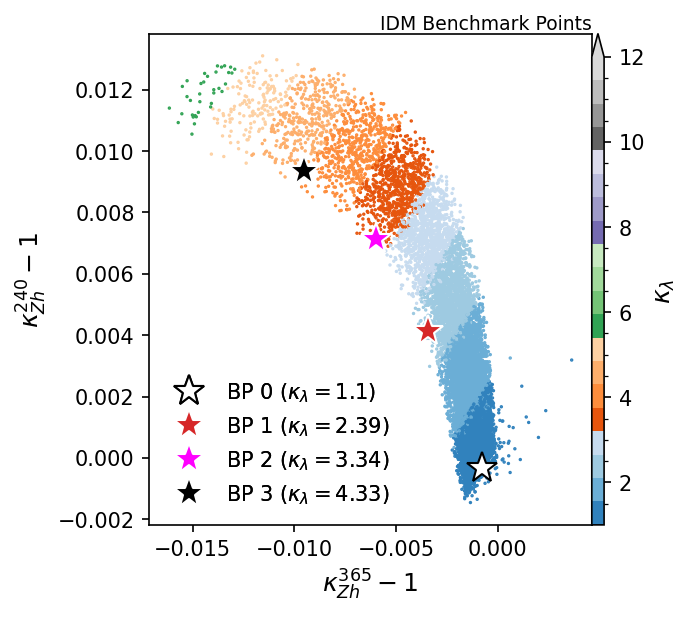

In [53]:
data_file = "data/IDM/allIDMpoints_2025-01-14"
plot_dir = "plots/IDM"
BR_constraints = 0.05
BPs_plot_final = ["BP_lambda1", "BPB_2", "BPB_4", "BPB_6", ]

BP_Names_legend_plot_final = [rf"BP {i} ($\kappa_\lambda=${bp_kappas[BP_Names.index(BP)]['lam']:.3g})"  for i, BP in enumerate(BPs_plot_final)]
bp_kappas_plot_final = [bp_kappas[BP_Names.index(BP)] for BP in BPs_plot_final]
print(bp_kappas_plot_final)
plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR"] - 1,
     BP["ZZ_240_with_WFR"] - 1,
     BP["lam"], 
     label ) for BP, label in zip(bp_kappas_plot_final, BP_Names_legend_plot_final)
]

plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                       BR_constraints=BR_constraints,
                       plot_points=plot_points_with_WFR,
                      #  point_colors="lambdas",
                       point_colors=["white", "tab:red", "fuchsia", "k"],
                       point_leg_columns=1,
                       point_leg_size=10,
                       legend_loc="lower left",
                      #  point_marker_size=[13, 10, 10],
                       point_marker_size=[15, 15, 15, 15],
                      #  point_markers=["*", "o", "^"],
                       point_markers=["*", "*", "*", "*"],
                       no_model_text=True,
                       upper_right_text="IDM Benchmark Points",
                    #    plot_name_suffix="_final_2pager",
                       markeredgewidth=[1, 1, 1, 1],
                       markeredgecolor=["black", "white", "white", "white"],
                       func_read_file_args={
                           'data_with_WFR': True,
                           'data_with_WFR_no_BSM_vertex': False,
                           'data_with_WFR_ZZh1L_hextlegonly': False
                       }
                )
plot_name= f"IDM_BPs_240_vs_365_{BR_constraints:0.3g}_SM_constraints_BPs_final"
plot_name_suffix="_with_WFR"
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14
Number of points satisfying the 5% SM constraint on the single higgs couplings: 14014 / 14048


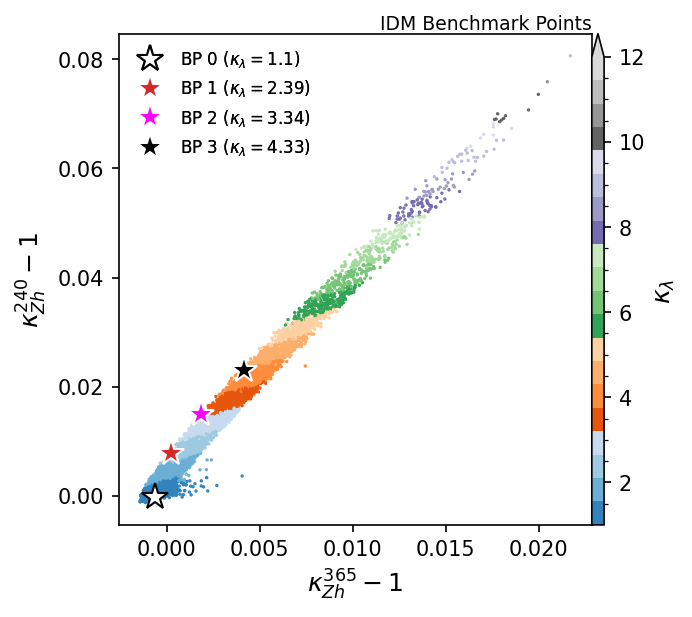

In [54]:
# Old, without Higgs WFR 
plot_points = [(BP["ZZ_365"]-1, BP["ZZ_240"]-1, BP["lam"], label) for BP, label in zip(bp_kappas_plot_final, BP_Names_legend_plot_final)]

plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                       BR_constraints=BR_constraints,
                       plot_points=plot_points,
                       point_colors=["white", "tab:red", "fuchsia", "k"],
                       point_leg_columns=1,
                       point_leg_size=8,
                       point_marker_size=[13, 13, 13, 13],
                       point_markers=["*", "*", "*", "*"],
                       no_model_text=True,
                       upper_right_text="IDM Benchmark Points",
                       markeredgewidth=[1, 1, 1, 1],
                       markeredgecolor=["black", "white", "white", "white"],
                )
plot_name= f"IDM_BPs_240_vs_365_{BR_constraints:0.3g}_SM_constraints_BPs_final"
plot_name_suffix=""
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+".pdf")

### Generate table with model parameters

In [55]:
model_pars_names = [
    r"$\mu_2^2\;[\si{\GeV^2}]$",
    r"$\lambda_1\;[\si{\GeV}]$",
    r"$\lambda_2\;[\si{\GeV}]$",
    r"$\lambda_3\;[\si{\GeV}]$",
    r"$\lambda_4\;[\si{\GeV}]$",
    r"$\lambda_5\;[\si{\GeV}]$",
    r"$m_H\;[\si{\GeV}]$",
    r"$m_A\;[\si{\GeV}]$",
    r"$m_{H^{\pm}}\;[\si{\GeV}]$",
]

model_pars = [
    "mu2sq", 
    "lam1", 
    "lam2", 
    "lam3", 
    "lam4", 
    "lam5", 
    "mH", 
    "mA", 
    "mHp",
]

first_line = ""
for par in model_pars_names:
    first_line = first_line + " & " + par
first_line = first_line + r" \\ \hline\hline"
print(first_line)

for i, BP in enumerate(BPs_plot_final):

    line = f"BP {i}"
    for par in model_pars:
        if par == "mu2sq":
            # line = line + f" & {bp_model_pars[BP_Names.index(BP)][par]:.6g}"
            line = line + rf" & \num[exponent-mode = scientific]{{{bp_model_pars[BP_Names.index(BP)][par]:.4}}}"
        else:
            line = line + f" & ${bp_model_pars[BP_Names.index(BP)][par]:.4g}$"
            # line = line + rf" & \SI{{{bp_model_pars[BP_Names.index(BP)][par]}}}"
    line = line + r" \\ \hline"
    print(line)

 & $\mu_2^2\;[\si{\GeV^2}]$ & $\lambda_1\;[\si{\GeV}]$ & $\lambda_2\;[\si{\GeV}]$ & $\lambda_3\;[\si{\GeV}]$ & $\lambda_4\;[\si{\GeV}]$ & $\lambda_5\;[\si{\GeV}]$ & $m_H\;[\si{\GeV}]$ & $m_A\;[\si{\GeV}]$ & $m_{H^{\pm}}\;[\si{\GeV}]$ \\ \hline\hline
BP 0 & \num[exponent-mode = scientific]{1.178e+06} & $0.2581$ & $6.213$ & $7.169$ & $-4.512$ & $-3.143$ & $1079$ & $1164$ & $1181$ \\ \hline
BP 1 & \num[exponent-mode = scientific]{3.666e+05} & $0.2581$ & $3.084$ & $11.46$ & $-5.68$ & $-5.109$ & $622.2$ & $834.8$ & $845.1$ \\ \hline
BP 2 & \num[exponent-mode = scientific]{3.922e+05} & $0.2581$ & $10.06$ & $14.19$ & $-6.974$ & $-6.407$ & $645.6$ & $897.3$ & $906.8$ \\ \hline
BP 3 & \num[exponent-mode = scientific]{3.432e+05} & $0.2581$ & $8.985$ & $15.83$ & $-7.704$ & $-7.4$ & $604.3$ & $902.1$ & $907.2$ \\ \hline


## Consistency checks: checking numerical values for $\delta Z_{h}$ and C1

Processing data file: data/IDM/allIDMpoints_2025-01-14


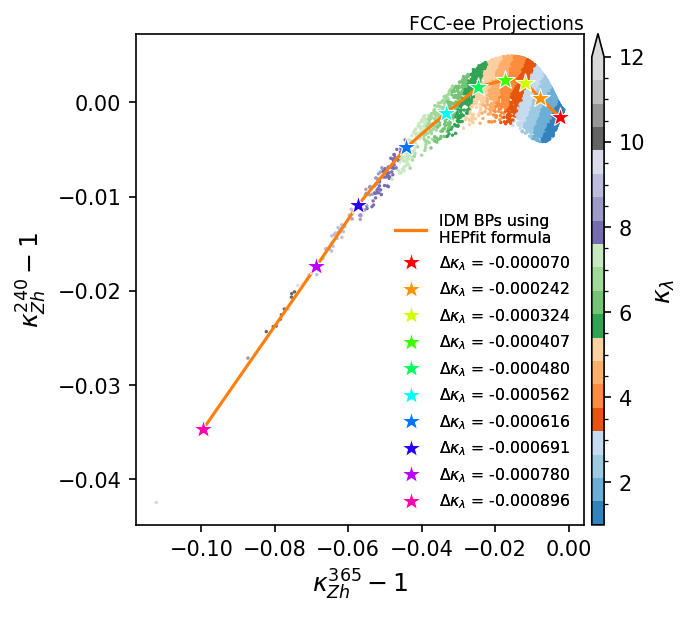

In [56]:
from utils.common_utils import analytical_formula_CH_CHBox_general_C1

def analytical_formula_Johannes_C1_values(mu_240, mu_365):
    return analytical_formula_CH_CHBox_general_C1(mu_240, mu_365, C1_values=c1_johannes)

plot_points_analytical_formula = []
for BP, label in zip(bp_kappas, BP_Names_legend):
    k_ZH_365 = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=BP["lam"], sqrt_s=365) + 2*(BP["uu"]-1))
    k_ZH_240 = sqrt(smeft_sigma_Zh_Johannes_C1_values(lmbd=BP["lam"], sqrt_s=240) + 2*(BP["uu"]-1))
    CH, CHBox, lmbd = analytical_formula_Johannes_C1_values(mu_240=k_ZH_240**2, mu_365=k_ZH_365**2)

    plot_points_analytical_formula.append((k_ZH_365-1, k_ZH_240-1, BP["lam"]-lmbd, label))

plot_points_analytical_formula = plot_points_analytical_formula[2::2]

fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'smeft_formula_Johannes_C1_values': True,
                        }
                )

data_sets = [plot_points_analytical_formula,]
legend_locs = ['lower right',]
legend_fontsizes = [6.0,]
markers = ["*", ]
markersizes = [10, ]
curves_matching_lambdas = ["IDM_HEPfit"]
file_names_matching_lambdas = [None,]
color_lines = ["tab:orange",]
label_lines = ['IDM BPs using\nHEPfit formula',]
legend_cols = [1,]
legend_fontsizes = [7.5,]
klam_in_point_labels = r"$\Delta \kappa_{\lambda}$"

plot_name_suffix = ""
plot_curves(ax, curves_matching_lambdas, file_names_matching_lambdas, data_sets, legend_locs, legend_cols, legend_fontsizes, markers, color_lines, label_lines, markersizes, klam_in_point_labels=klam_in_point_labels, color_independent=True)
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_Johannes_C1_values_matching_lambdas_dkala_analytical.pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14


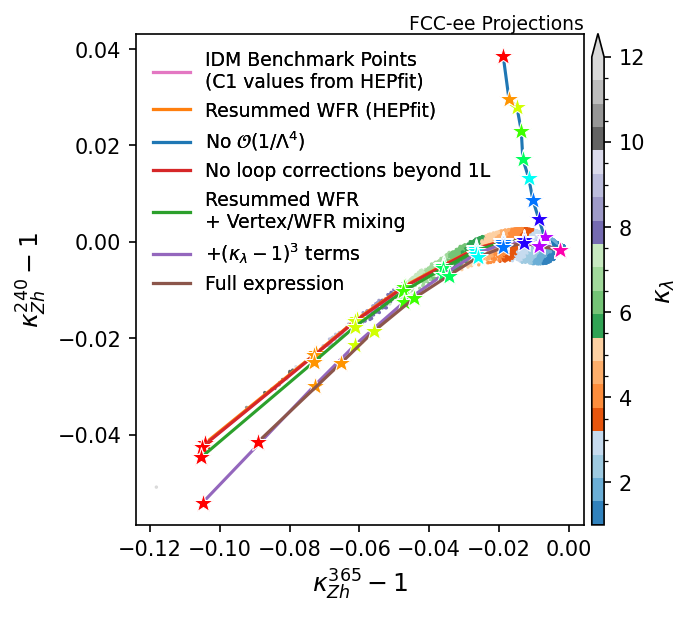

In [57]:
########################################################
### data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values ###
########################################################
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )

plot_points_with_WFR = [
    (BP["ZZ_365_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values"] - 1,
     BP["ZZ_240_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values"] - 1,
     BP["lam"],
     label, ) for BP, label in zip(bp_kappas, BP_Names_legend)
]
plot_points_with_WFR = plot_points_with_WFR[2::2]

color_lines = [
    "tab:pink",
    "tab:orange",
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:brown",
]
label_lines = [
    r'IDM Benchmark Points'+'\n'+'(C1 values from HEPfit)',
    r'Resummed WFR (HEPfit)', # r'HEPfit formula',
    r'No $\mathcal{O}(1/\Lambda^4)$',
    r'No loop corrections beyond 1L',
    r'Resummed WFR '+'\n'+'+ Vertex/WFR mixing', # r'$+ 2(\kappa_{\lambda}-1)^2 C1 \dfrac{\delta Z_h}{1-\delta Z_h}$',
    r'$+(\kappa_{\lambda}-1)^3$ terms',
    r'Full expression',
]
curves_uncertainty_estimation = [
    "IDM",
    "HEPfit", 
    "noLoopH3d6Quad",
    "LoopHd6NoSubleading",
    "LoopH3d6Quad_C1term",
    "LoopH3d6Cubi",
    "LoopH3d6Full",
]
data_sets = [
    plot_points_with_WFR,
    None,
    None,
    None,
    None,
    None,
    None,
]
results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs_.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__noLoopH3d6Quad.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Quad_C1term.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Cubi.txt",
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopH3d6Full.txt",
]
n_curves = len(k_ZH_240_365_predictions_file_names)
legend_locs = [None, None, None, None, None, None, "upper left",]
legend_cols = [1 for _ in range(n_curves)]
legend_fontsizes = [9.0 for _ in range(n_curves)]
markers = ["*" for _ in range(n_curves)]
markersizes = [10 for _ in range(n_curves)]
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)
plot_name = "Uncertainties_final_plot"
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_curves.pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14


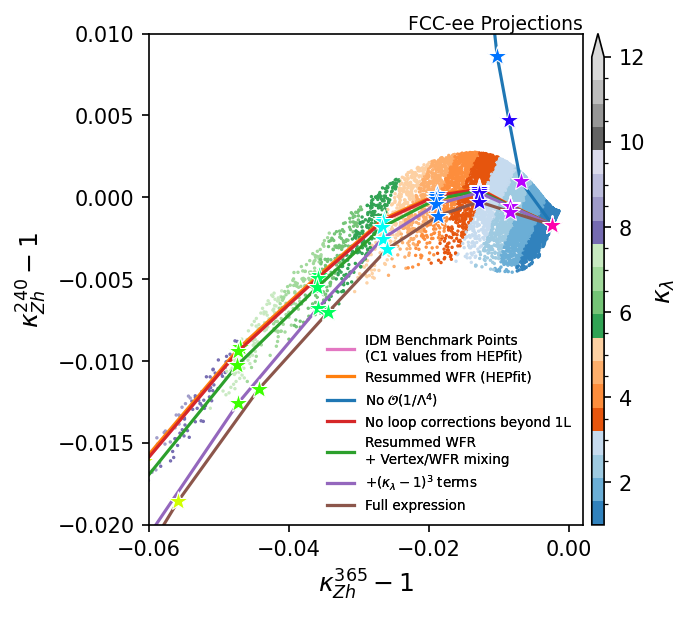

In [58]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )
legend_locs = [None, None, None, None, None, None, 'lower right',]
legend_fontsizes = [6.5 for _ in range(n_curves)]
plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
plt.show()
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_curves_zoom.pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14


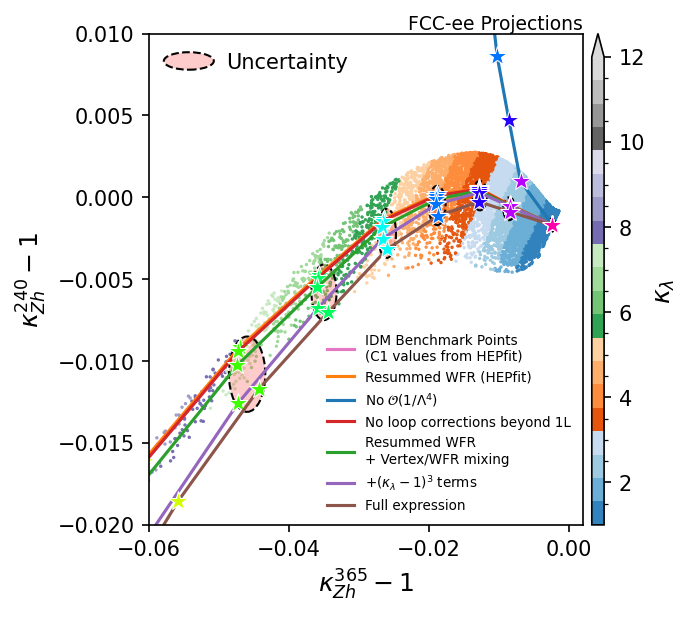

In [59]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )       

plot_curves (
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)

xs     = [-2.4e-3, -0.0085, -0.0127, -0.0188,  -0.026, -0.035, -0.0460, ]
ys     = [-1.7e-3, -7.0e-4,  0.0001,  -0.0005, -0.0022, -0.0058, -0.0108, ]
err_xs = [0.5e-3,   0.85e-3,  1.0e-3,  1.2e-3,  1.3e-3, 1.8e-3, 2.6e-3, ]
err_ys = [4.0e-4,   0.7e-3,  0.9e-3,  1.2e-3,  1.5e-3, 1.7e-3, 2.3e-3, ] 
black = (0,0,0,1)
red_face = (1,0,0,0.2)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)

ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+f"_HEPfit_C1_values_curves_zoom_ellipses.pdf")

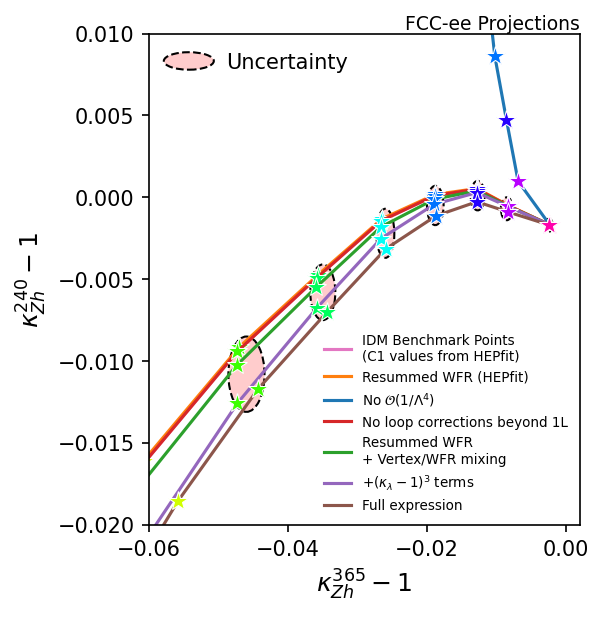

In [60]:
fig, ax = plt.subplots(
    figsize=(3.91, 4.0),
    constrained_layout=True)

ax.set_xlabel(r'$\kappa_{Zh}^{365} - 1$')
ax.set_ylabel(r'$\kappa_{Zh}^{240} - 1$')

text_collider = "FCC-ee Projections"
ax.text(
    1,
    1,
    text_collider,
    horizontalalignment="right",
    verticalalignment="bottom",
    transform=ax.transAxes,
    fontsize=9,
)

plot_curves(
    ax,
    curves_uncertainty_estimation, 
    k_ZH_240_365_predictions_file_names, 
    data_sets, 
    legend_locs, 
    legend_cols, 
    legend_fontsizes,
    markers, 
    color_lines, 
    label_lines, 
    markersizes,
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
for x, y, err_x, err_y in zip(xs, ys, err_xs, err_ys):
    ellipse = Ellipse((x, y), width=err_x*2, height=err_y*2, edgecolor=black, facecolor=red_face, linestyle='--')
    ax.add_patch(ellipse)

ax.legend(handles=[ellipse], labels=[r"Uncertainty"], loc='upper left', fontsize=10.0, frameon=False, handler_map={Ellipse: HandlerEllipse()})
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+f"_HEPfit_C1_values_curves_zoom_ellipses_no_bulk.pdf")

klam = [1.1209067864736006, 2.3867362274064843, 3.3446699219962595, 4.332584967850238, 5.390968560325193, 6.370034303736775, 7.515862276796717]
Mean k_Zh uncertainties: 240: 0.0005375, 365: 0.00054375
kappas_Zh_365 = [0.9976417725701672, 0.9916328809204834, 0.9871694928987288, 0.9810915287606191, 0.9734031982701472, 0.9641090108657624, 0.9527062984094574, 0.9388217084579715, 0.9271025711482412, 0.8949539637123386]
kappas_Zh_240 = [0.9983262758557929, 0.9995028213528719, 1.0004990643816172, 1.0000993940316913, 0.9985648357188562, 0.9950816913524158, 0.9905950407491717, 0.9835627522603577, 0.9764884453327103, 0.9575009581461474]
mean_kappas_Zh = [0.9805547399764984, 0.9997210980440548]
Mean sigma_Zh uncertainties: 240: 0.001074700180397359, 365: 0.0010663532797244419


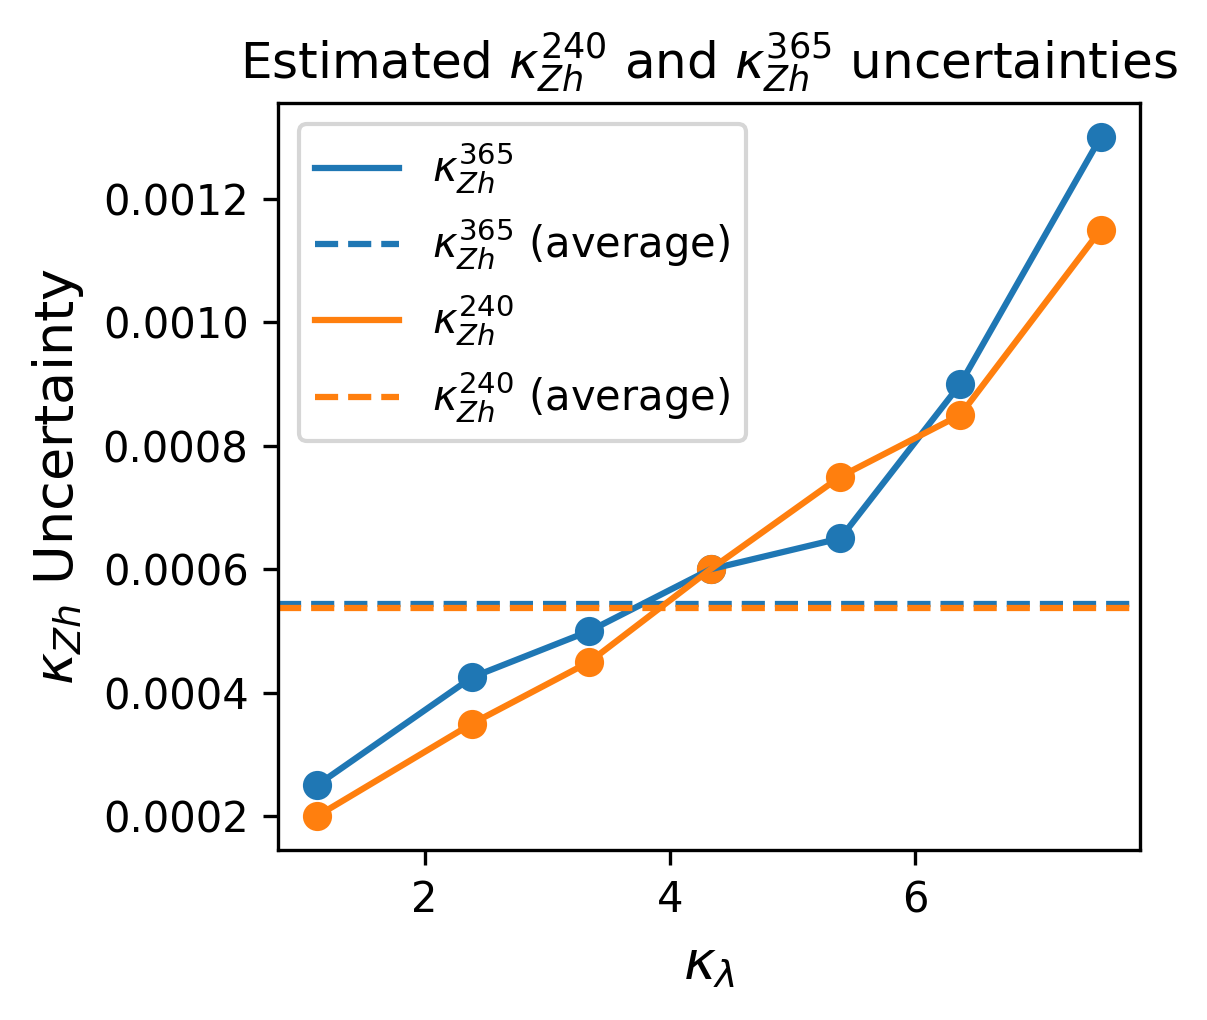

In [61]:
fig, ax = plt.subplots(figsize=(4.0, 3.5), dpi=300)
curves = [0.5*np.array(err_xs), 0.5*np.array(err_ys)]
labels = [r"$\kappa_{Zh}^{365}$", r"$\kappa_{Zh}^{240}$"]
colors = ["tab:blue", "tab:orange",]

mean_uncertainties_kappa = [np.mean(curve[1:5]) for curve in curves]

klam = [ plot_points_with_WFR[i][2] for i in range(len(err_xs)) ]
print(f"klam = {klam}")
for curve, label, color, mean in zip(curves, labels, colors, mean_uncertainties_kappa):
    plt.plot(klam, curve, label=label, color=color)
    plt.scatter(klam, curve, color=color)

    plt.axhline(y=mean, linestyle='--', linewidth=1.5, color=color, label=label+" (average)")
    
plt.xlabel(r"$\kappa_\lambda$", fontsize=13)
plt.title(r"Estimated $\kappa_{Zh}^{240}$ and $\kappa_{Zh}^{365}$ uncertainties")
plt.ylabel(r"$\kappa_{Zh}$ Uncertainty", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_k_ZH_240_365_uncertainties.pdf")

print(f"Mean k_Zh uncertainties: 240: {mean_uncertainties_kappa[1]}, 365: {mean_uncertainties_kappa[0]}")
kappas_Zh_365 = [ (lst[0]+1) for lst in plot_points_with_WFR]
print(f"kappas_Zh_365 = {kappas_Zh_365}")
kappas_Zh_240 = [ (lst[1]+1) for lst in plot_points_with_WFR]
print(f"kappas_Zh_240 = {kappas_Zh_240}")
kappas_Zh = [ kappas_Zh_365[1:5], kappas_Zh_240[1:5]]

mean_kappas_Zh = [np.mean(ks[1:5]) for ks in kappas_Zh]
print(f"mean_kappas_Zh = {mean_kappas_Zh}")
mean_uncertainties_sigma = [2*kappa*mean for kappa, mean in zip(mean_kappas_Zh, mean_uncertainties_kappa)]
print(f"Mean sigma_Zh uncertainties: 240: {mean_uncertainties_sigma[1]}, 365: {mean_uncertainties_sigma[0]}")

Processing data file: data/IDM/allIDMpoints_2025-01-14


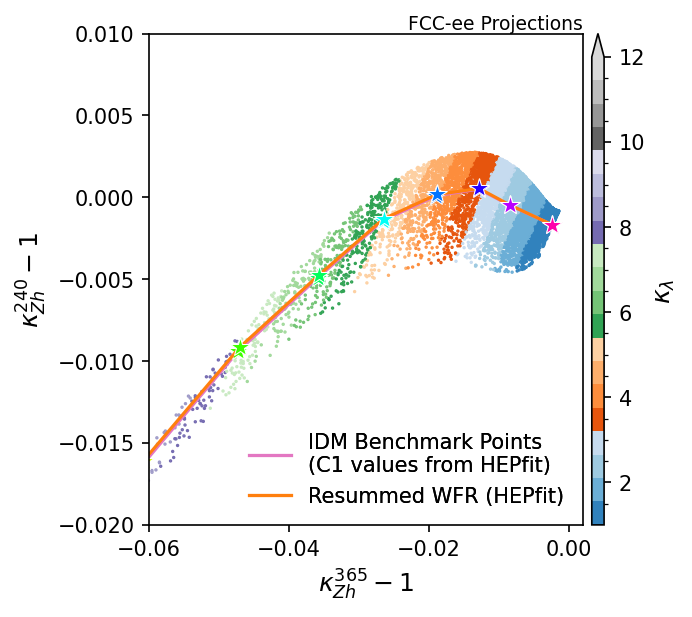

In [62]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )
legend_locs = [None, 'lower right',]
legend_fontsizes = [10.0, 10.0,]
plot_curves (
    ax,
    curves_uncertainty_estimation[:2], 
    k_ZH_240_365_predictions_file_names[:2], 
    data_sets[:2], 
    legend_locs[:2], 
    legend_cols[:2], 
    legend_fontsizes[:2],
    markers[:2], 
    color_lines[:2], 
    label_lines[:2], 
    markersizes[:2],
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_curves_zoom_only_hepfit.pdf")

Processing data file: data/IDM/allIDMpoints_2025-01-14


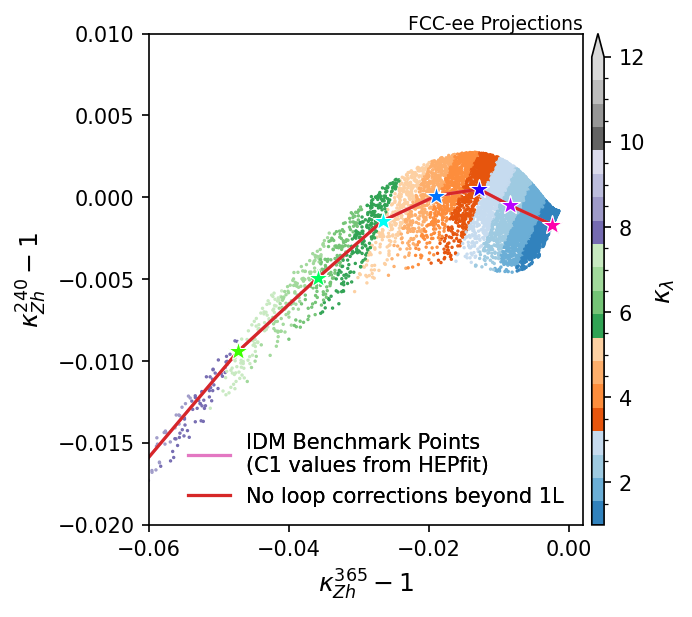

In [63]:
fig, ax = plot_EffZZH_240_vs_365(data_file, read_IDM_file,
                        no_model_text=True, upper_right_text=upper_right_text,
                        func_read_file_args={
                            'data_with_WFR': False,
                            'data_with_WFR_no_BSM_vertex': False,
                            'data_with_WFR_ZZh1L_hextlegonly': False,
                            'data_with_WFR_ZZh1L_hextlegonly_HEPfit_C1_values': True
                        }
                )
legend_locs = [None, 'lower right',]
legend_fontsizes = [10.0, 10.0,]
curves_uncertainty_estimation = ["IDM", "LoopHd6NoSubleading",]
color_lines = ["tab:pink", "tab:red",]

results_directory = "/cephfs/user/mrebuzzi/phd/HEPfit/HEPfit_snowmass21/IDM_fits/Uncertainty_estimation/comparison_plots"
k_ZH_240_365_predictions_file_names = [
    None,
    f"{results_directory}/k_ZH_240_365_predictions_BPs__LoopHd6NoSubleading.txt",
]
label_lines = [
    r'IDM Benchmark Points'+'\n'+'(C1 values from HEPfit)',
    r'No loop corrections beyond 1L',
]
plot_curves (
    ax,
    curves_uncertainty_estimation[:2], 
    k_ZH_240_365_predictions_file_names[:2], 
    data_sets[:2], 
    legend_locs[:2], 
    legend_cols[:2], 
    legend_fontsizes[:2],
    markers[:2], 
    color_lines[:2], 
    label_lines[:2], 
    markersizes[:2],
    input_file_layout="CH_CHbox",
    klam_in_point_labels=None,
    # max_n_markers=10
)

ax.set_xlim(-0.06, +0.002)
ax.set_ylim(-0.02, +0.01)
fig.savefig(f'{plot_dir}/{plot_name}{plot_name_suffix}'+"_HEPfit_C1_values_curves_zoom_only_noresum.pdf")